<div align="right">
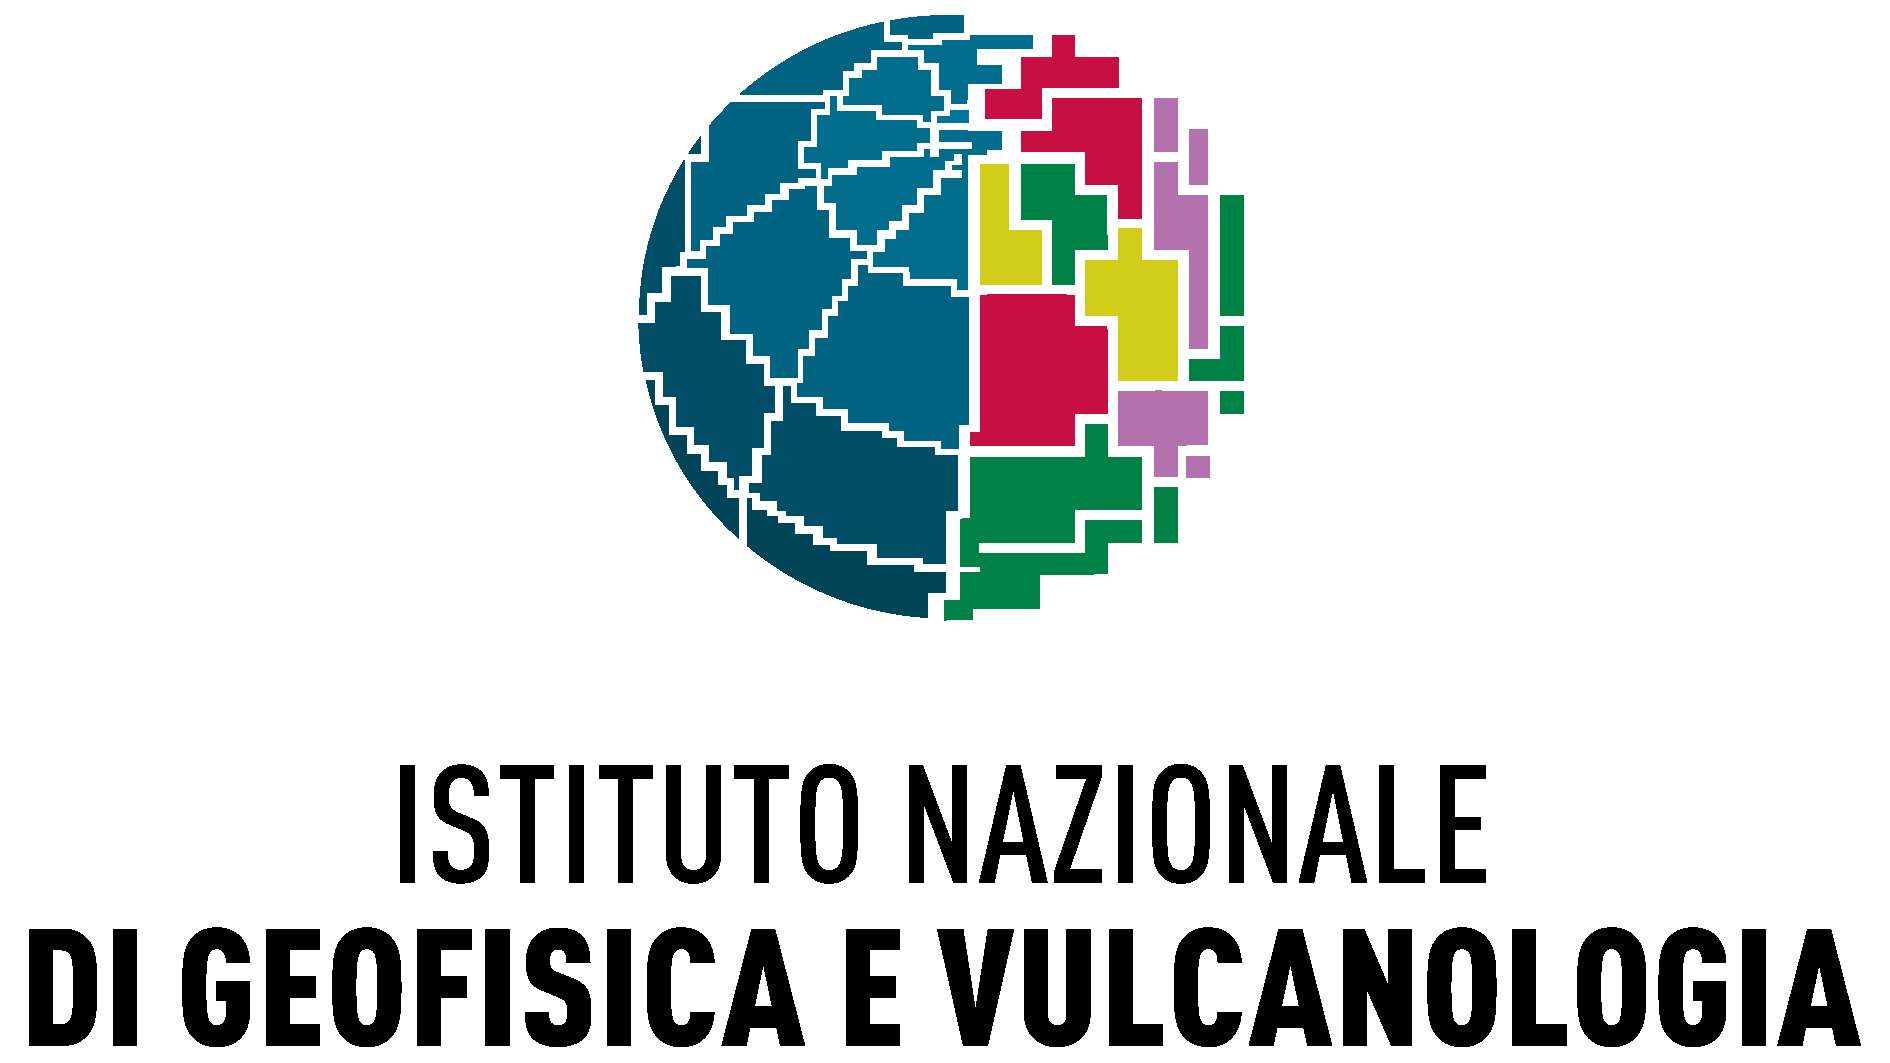
</div>

# 📡 TEC Evaluation from GNSS Measurements
### Interactive Learning Notebook



---
## How to use this notebook

This notebook is supposed to be used as the lecture slides. Work through the cells **in order**:

| Section | Topic | Type |
|---|---|---|
| §1 | GNSS & the ionosphere | Theory + figures |
| §2 | GNSS observables and the GFLC | Theory + figures |
| §3 | Biases and the Gg calibration | Theory + figures |
| §4 | PyTECGg — from RINEX to calibrated TEC | Code |
| §5 | Exercises | Hands-on |

> 💡 **Tip:** Run each cell with `Shift+Enter`. Figure cells are self-contained — they generate the plots from scratch using `matplotlib`.


---
## <span style="color:#38bdf8">About this event</span>

<div style="border-left: 4px solid #38bdf8; padding: 0.6em 1em; background: rgba(56,189,248,0.08);">

**International School and Workshop on Space Weather** (SMR 4236)

📍 **ICTP** — Giambiagi Lecture Hall, Adriatico Guest House, Trieste, Italy
📅 **14–18 September 2026**

This notebook is presented as part of the capacity-building programme on space weather phenomena, with emphasis on ionospheric effects on technological systems and GNSS applications — targeted in particular at strengthening research capabilities across Africa.

Presented by **C. Cesaroni** (INGV)

</div>

---

---
## <span style="color:#2dd4bf">GNSS: a quick refresher</span>

### What is GNSS?

<span style="color:#fbbf24">**GNSS (Global Navigation Satellite System)**</span> is the general term for satellite-based positioning systems. All GNSS constellations transmit signals on **at least two frequencies**, enabling the removal of the ionospheric delay.

| Constellation | Agency | # Satellites | Frequencies |
|---|---|---|---|
| **GPS** (USA) | USAF | 31 | L1 1575.42 MHz, L2 1227.60 MHz |
| **GLONASS** (Russia) | Roscosmos | 24 | L1 ~1602 MHz, L2 ~1246 MHz |
| **Galileo** (EU) | ESA/EC | 36 | E1 1575.42 MHz, E5a 1176.45 MHz |
| **BeiDou** (China) | CNSA | 48 | B1 1561.10 MHz, B2 1207.14 MHz |
| **QZSS** (Japan) | JAXA | 7 | L1, L2, L5 |
| **NavIC** (India) | ISRO | 9 | L5 1176.45 MHz, S 2492.08 MHz |

### The pseudorange equation

$$\boxed{P_i = \rho + c\,\delta t + I_i + T + \varepsilon_P}$$

where:
- $\color{#a78bfa}{\rho}$ = geometric satellite–receiver range  
- $\color{#a78bfa}{c\,\delta t}$ = clock offset  
- $\color{#f87171}{I_i = 40.3\,\text{TEC}/f_i^2}$ = ionospheric delay **(dispersive — frequency-dependent)**  
- $\color{#fbbf24}{T}$ = tropospheric delay (non-dispersive)

> <span style="color:#34d399">💡 **Key idea:** because </span>$\color{#34d399}{I_i \propto f_i^{-2}}$<span style="color:#34d399">, measuring on two frequencies lets us isolate TEC — this is the foundation of the whole notebook.</span>


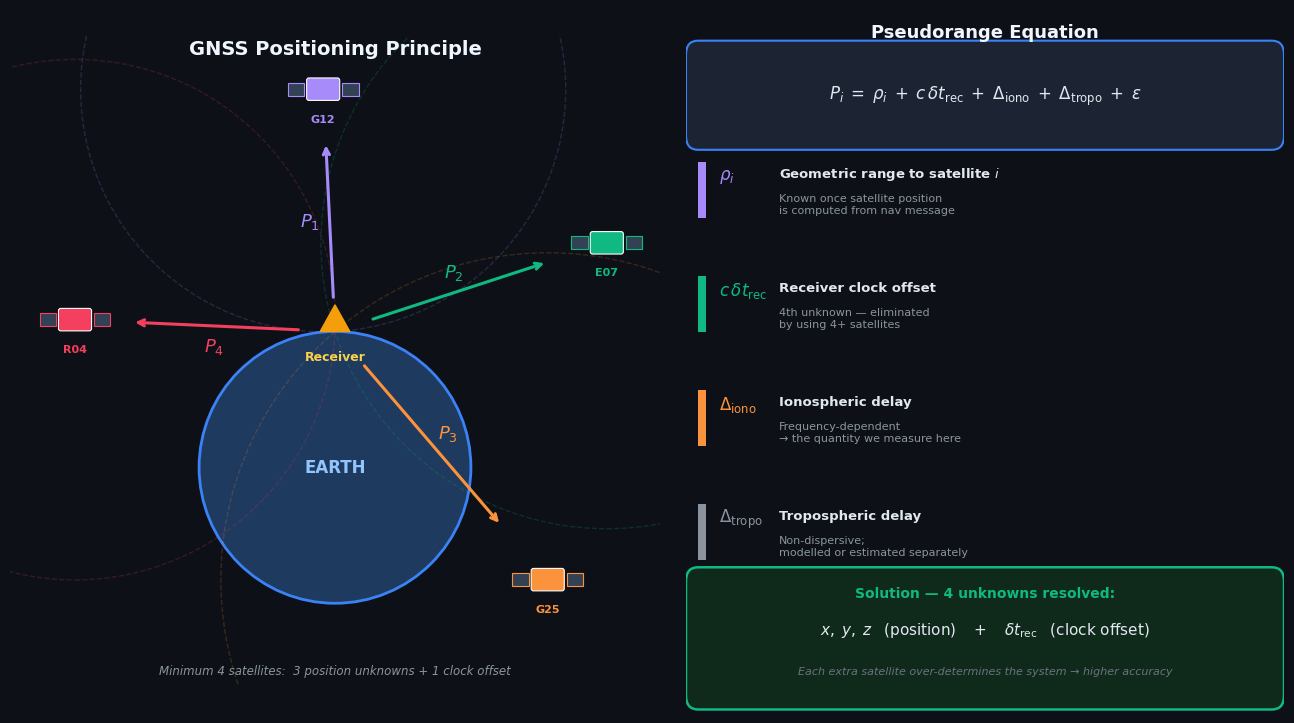

Figure 0: GNSS positioning principle


In [23]:
# ── Figure 0: GNSS positioning principle ──────────────────────────────────────
# LEFT  — 4 satellites transmitting pseudoranges P1–P4 to a ground receiver.
#          Dashed circles show the range sphere from each satellite.
# RIGHT — Pseudorange equation with each term colour-coded and explained,
#          plus the solution box showing the 4 unknowns resolved.

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Circle, Polygon, FancyBboxPatch

fig = plt.figure(figsize=(13, 8), facecolor='#0d1117')
ax_geo = fig.add_axes([0.01, 0.08, 0.50, 0.88])
ax_eq  = fig.add_axes([0.53, 0.08, 0.46, 0.88])
for ax in [ax_geo, ax_eq]:
    ax.set_facecolor('#0d1117')
    ax.axis('off')

# ── LEFT: geometry ─────────────────────────────────────────────────────────────
ax_geo.set_xlim(-5.5, 5.5); ax_geo.set_ylim(-5.2, 5.8); ax_geo.set_aspect('equal')

ax_geo.text(0, 5.5, 'GNSS Positioning Principle',
            ha='center', fontsize=14, fontweight='bold', color='#f0f6ff')
ax_geo.add_patch(Circle((0,-1.5), 2.3, color='#1e3a5f', zorder=1))
ax_geo.add_patch(Circle((0,-1.5), 2.3, color='#3b82f6', fill=False, lw=2, zorder=2))
ax_geo.text(0,-1.5,'EARTH',ha='center',va='center',fontsize=12,color='#93c5fd',fontweight='bold',zorder=3)

rx = np.array([0.0, 0.8])
ax_geo.add_patch(Polygon([rx+[-0.25,0],rx+[0.25,0],rx+[0,0.45]],closed=True,color='#f59e0b',zorder=8))
ax_geo.text(rx[0],rx[1]-0.48,'Receiver',ha='center',fontsize=9,color='#fcd34d',fontweight='bold')

def draw_sat(ax, sx, sy, col):
    ax.add_patch(FancyBboxPatch((sx-0.24,sy-0.15),0.48,0.30,boxstyle='round,pad=0.04',
                                facecolor=col,edgecolor='white',lw=0.8,zorder=9))
    for dx in [-0.58, 0.34]:
        ax.add_patch(FancyBboxPatch((sx+dx,sy-0.09),0.24,0.18,boxstyle='square,pad=0.02',
                                    facecolor='#334155',edgecolor=col,lw=0.8,zorder=9))

sats = [(-0.2,4.9,'#a78bfa','G12',r'$P_1$'),(4.6,2.3,'#10b981','E07',r'$P_2$'),
        (3.6,-3.4,'#fb923c','G25',r'$P_3$'),(-4.4,1.0,'#f43f5e','R04',r'$P_4$')]
for sx,sy,col,svid,plabel in sats:
    sat = np.array([sx,sy]); dist = np.linalg.norm(sat-rx)
    ax_geo.add_patch(Circle(sat,dist,color=col,fill=False,lw=1.0,ls='--',alpha=0.18,zorder=3))
    ax_geo.annotate('',xy=rx+(sat-rx)*0.78,xytext=rx+(sat-rx)*0.13,
                    arrowprops=dict(arrowstyle='->',color=col,lw=2.2),zorder=6)
    mid=rx+(sat-rx)*0.46; perp=np.array([-(sy-rx[1]),sx-rx[0]])
    if np.linalg.norm(perp)>0: perp=perp/np.linalg.norm(perp)*0.34
    ax_geo.text(mid[0]+perp[0],mid[1]+perp[1],plabel,ha='center',va='center',
                fontsize=13,color=col,fontweight='bold',zorder=7)
    draw_sat(ax_geo,sx,sy,col)
    ax_geo.text(sx,sy-0.55,svid,ha='center',fontsize=8,color=col,fontweight='bold')

ax_geo.text(0,-5.0,'Minimum 4 satellites:  3 position unknowns + 1 clock offset',
            ha='center',fontsize=8.5,color='#8b949e',style='italic')

# ── RIGHT: equation breakdown ──────────────────────────────────────────────────
ax_eq.set_xlim(0,10); ax_eq.set_ylim(0,10)
ax_eq.text(5,9.6,'Pseudorange Equation',ha='center',fontsize=13,fontweight='bold',color='#f0f6ff')
ax_eq.add_patch(FancyBboxPatch((0.2,8.2),9.6,1.15,boxstyle='round,pad=0.2',
                               facecolor='#1c2333',edgecolor='#3b82f6',lw=1.5))
ax_eq.text(5,8.77,
    r'$P_i \;=\; \rho_i \;+\; c\,\delta t_{\mathrm{rec}} \;+\; \Delta_{\mathrm{iono}} \;+\; \Delta_{\mathrm{tropo}} \;+\; \varepsilon$',
    ha='center',va='center',fontsize=12,color='#e2e8f0')

terms = [
    (r'$\rho_i$',          'Geometric range to satellite $i$',     'Known once satellite position\nis computed from nav message',      '#a78bfa'),
    (r'$c\,\delta t_{\mathrm{rec}}$','Receiver clock offset',  '4th unknown — eliminated\nby using 4+ satellites',        '#10b981'),
    (r'$\Delta_{\mathrm{iono}}$','Ionospheric delay',            'Frequency-dependent\n\u2192 the quantity we measure here',  '#fb923c'),
    (r'$\Delta_{\mathrm{tropo}}$','Tropospheric delay',           'Non-dispersive;\nmodelled or estimated separately',         '#8b949e'),
]
y0 = 7.55
for sym,title,detail,col in terms:
    ax_eq.add_patch(FancyBboxPatch((0.2,y0-0.52),0.13,0.80,boxstyle='square,pad=0',facecolor=col,edgecolor='none'))
    ax_eq.text(0.55,y0+0.08,sym,  fontsize=12,color=col,fontweight='bold',va='center')
    ax_eq.text(1.55,y0+0.12,title,fontsize=9.5,color='#e2e8f0',va='center',fontweight='bold')
    ax_eq.text(1.55,y0-0.32,detail,fontsize=8,color='#8b949e',va='center')
    y0 -= 1.62

ax_eq.add_patch(FancyBboxPatch((0.2,0.25),9.6,1.62,boxstyle='round,pad=0.2',
                               facecolor='#0f2a1a',edgecolor='#10b981',lw=1.8))
ax_eq.text(5,1.65,'Solution \u2014 4 unknowns resolved:',ha='center',fontsize=10,color='#10b981',fontweight='bold')
ax_eq.text(5,1.12,r'$x,\;y,\;z \;\;$ (position)$\quad+\quad\delta t_{\mathrm{rec}}\;\;$ (clock offset)',
           ha='center',fontsize=11,color='#e2e8f0')
ax_eq.text(5,0.55,'Each extra satellite over-determines the system \u2192 higher accuracy',
           ha='center',fontsize=8,color='#6b7280',style='italic')

plt.savefig('fig0_gnss_positioning.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Figure 0: GNSS positioning principle")


---
## <span style="color:#2dd4bf">GNSS Signals and the Ionosphere</span>

### <span style="color:#fbbf24">1.1 The Appleton–Hartree equation</span>

The refractive index $n$ of the ionosphere is described by the **Appleton–Hartree equation**:

$$n^2 = 1 - \frac{X}{1 - \frac{Y_T^2/2}{1-X} \pm \sqrt{\left(\frac{Y_T^2/2}{1-X}\right)^2 + Y_L^2}}$$

where:
- $\color{#a78bfa}{X = f_N^2/f^2}$ — electron plasma frequency term  
- $\color{#a78bfa}{Y_T, Y_L}$ — electron gyro-frequency terms (transverse / longitudinal)

For GNSS frequencies ($f \gg f_N,\, f_H$), collisions are negligible and the **1st-order expansion** gives:

$$\boxed{n \approx 1 - \frac{40.3\,N_e}{f^2}}$$

> <span style="color:#f87171">⚠️ Higher-order terms (</span>$\color{#f87171}{\propto f^{-3}}$<span style="color:#f87171">, </span>$\color{#f87171}{f^{-4}}$<span style="color:#f87171">) are <0.1% for GPS/Galileo and are usually ignored — but matter for very precise applications.</span>

The **optical path** of a GNSS signal from satellite to receiver becomes:

$$L = \int n\,ds = \rho - \frac{40.3}{f^2}\underbrace{\int N_e\,ds}_{\text{TEC}}$$

$$\boxed{\text{TEC} = \int_{\text{path}} N_e\,ds \quad [\text{TECU} = 10^{16}\,\text{el/m}^2]}$$

- <span style="color:#34d399">**Phase** is **advanced** (shorter apparent path)</span>  
- <span style="color:#f87171">**Code** is **delayed** (longer apparent path)</span>  
- Both effects scale as $f^{-2}$ → **measuring at two frequencies isolates TEC**


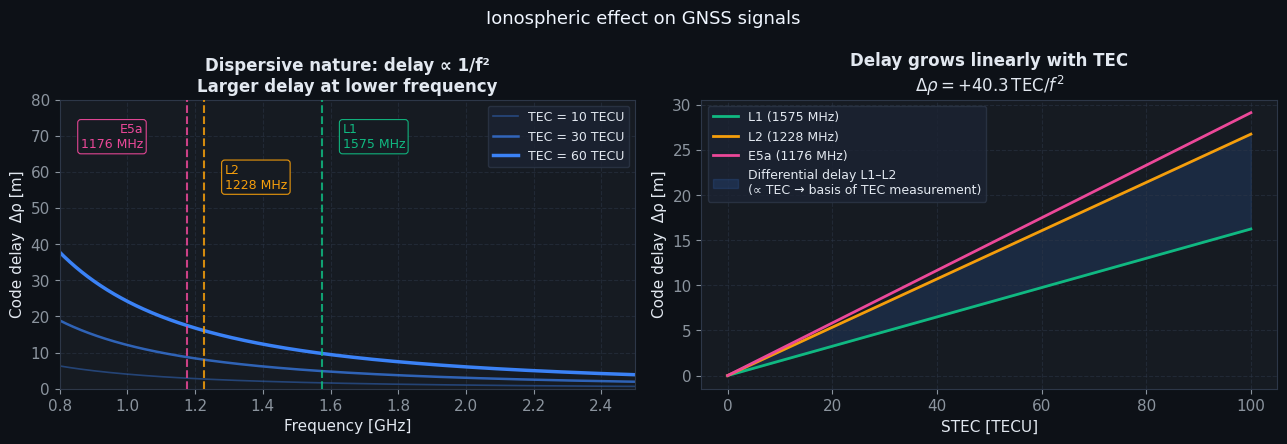

Figure 1: left = dispersive delay vs frequency | right = delay vs TEC


In [24]:
# ── Figure 1: Ionospheric effect on GNSS signals ─────────────────────────────
# LEFT  — Code delay vs frequency for fixed TEC: shows the dispersive nature
#          of the ionosphere (delay ∝ 1/f²). GNSS uses two frequencies
#          precisely because this frequency-dependence allows TEC measurement.
# RIGHT — Code delay vs TEC at L1, L2, E5a: the differential delay between
#          two frequencies is proportional to TEC — the basis of TEC retrieval.

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.transforms import blended_transform_factory

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#2d3748', 'text.color': '#e2e8f0',
    'axes.labelcolor': '#e2e8f0', 'xtick.color': '#8b949e',
    'ytick.color': '#8b949e', 'grid.color': '#2d3748',
    'grid.linestyle': '--', 'grid.alpha': 0.5,
    'font.size': 11, 'axes.titlesize': 12, 'axes.titleweight': 'bold'
})

f_L1 = 1575.42e6   # GPS L1 / Galileo E1
f_L2 = 1227.60e6   # GPS L2
f_E5 = 1176.45e6   # Galileo E5a

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Ionospheric effect on GNSS signals', color='#f0f6ff', fontsize=13)

# ── LEFT: code delay vs frequency ─────────────────────────────────────────────
ax = axes[0]
f_range = np.linspace(0.5e9, 3e9, 1000)

for TEC_val, alpha, lw in [(10, 0.4, 1.2), (30, 0.7, 1.8), (60, 1.0, 2.5)]:
    delay = 40.3 * TEC_val / f_range**2 * 1e16
    ax.plot(f_range/1e9, delay, color='#3b82f6', lw=lw, alpha=alpha,
            label=f'TEC = {TEC_val} TECU')

# Labels use a blended transform (data x, axes-fraction y) so they sit at
# fixed heights regardless of data scale — E5a left of its line, L2 below,
# L1 right of its line, all well separated.
trans = blended_transform_factory(ax.transData, ax.transAxes)
label_cfg = [
    (f_E5, 'E5a\n1176 MHz', '#ec4899', -0.13, 0.92, 'right', 'top'),
    (f_L2, 'L2\n1228 MHz',  '#f59e0b',  0.06, 0.78, 'left',  'top'),
    (f_L1, 'L1\n1575 MHz',  '#10b981',  0.06, 0.92, 'left',  'top'),
]
for ff, label, col, dx, y_ax, ha, va in label_cfg:
    ax.axvline(ff/1e9, color=col, lw=1.5, ls='--', alpha=0.85, zorder=5)
    ax.text(ff/1e9 + dx, y_ax, label, transform=trans,
            color=col, fontsize=9, ha=ha, va=va,
            bbox=dict(boxstyle='round,pad=0.25', fc='#161b22',
                      ec=col, lw=0.8, alpha=0.95))

ax.set_xlabel('Frequency [GHz]')
ax.set_ylabel('Code delay  Δρ [m]')
ax.set_title('Dispersive nature: delay ∝ 1/f²\nLarger delay at lower frequency')
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim(0.8, 2.5)
ax.set_ylim(0, 80)
ax.grid(True)

# ── RIGHT: code delay vs TEC ───────────────────────────────────────────────────
ax2 = axes[1]
TEC = np.linspace(0, 100, 200)
delay_L1 = 40.3 * TEC / f_L1**2 * 1e16
delay_L2 = 40.3 * TEC / f_L2**2 * 1e16
delay_E5 = 40.3 * TEC / f_E5**2 * 1e16

ax2.plot(TEC, delay_L1, color='#10b981', lw=2, label='L1 (1575 MHz)')
ax2.plot(TEC, delay_L2, color='#f59e0b', lw=2, label='L2 (1228 MHz)')
ax2.plot(TEC, delay_E5, color='#ec4899', lw=2, label='E5a (1176 MHz)')
ax2.fill_between(TEC, delay_L1, delay_L2, alpha=0.15, color='#3b82f6',
                 label='Differential delay L1–L2\n(∝ TEC → basis of TEC measurement)')
ax2.set_xlabel('STEC [TECU]')
ax2.set_ylabel('Code delay  Δρ [m]')
ax2.set_title('Delay grows linearly with TEC\n'
              r'$\Delta\rho = +40.3\,\mathrm{TEC}/f^2$')
ax2.legend(fontsize=9)
ax2.grid(True)

plt.tight_layout()
plt.savefig('fig1_ionospheric_delay.png', dpi=120, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print("Figure 1: left = dispersive delay vs frequency | right = delay vs TEC")


### <span style="color:#fbbf24">1.2 Total Electron Content (TEC)</span>

<span style="color:#fbbf24">**TEC**</span> is defined as the **line integral of electron density** $N_e$ along the signal path:

$$\text{TEC} = \int_{\text{path}} N_e\,ds \qquad [\text{TECU} = 10^{16}\,\text{el/m}^2]$$

**Typical values:**

| Condition | TEC [TECU] |
|---|---|
| Night, quiet sun | 1–10 |
| Day, quiet sun | 10–40 |
| Day, high solar activity | 50–100 |
| Extreme solar storm | >200 |

**Ionospheric delays at GPS L1 (1575.42 MHz):**

$$\Delta\rho_{L1} = \frac{40.3}{f_{L1}^2} \cdot \text{TEC} \approx 0.162 \times \text{TEC [m/TECU]}$$

> <span style="color:#34d399">💡 At 30 TECU (typical daytime), the delay on L1 is ~4.9 m — large enough to degrade positioning by several metres if not corrected.</span>


---
## <span style="color:#2dd4bf">GNSS Observables and the Geometry-Free Combination</span>

### <span style="color:#fbbf24">2.1 Phase and code measurement equations</span>

A GNSS receiver produces two types of observables at each frequency $f_i$:

$$\boxed{L_i = \rho + c\,\delta t - I_i + T + N_i\lambda_i + \underbrace{b^{\text{sat}}_i + b^{\text{rec}}_i}_{\text{IFB}} + \varepsilon_L}$$

$$\boxed{P_i = \rho + c\,\delta t + I_i + T + \underbrace{B^{\text{sat}}_i + B^{\text{rec}}_i}_{\text{DCB}} + \varepsilon_P}$$

- $\color{#a78bfa}{\rho}$ = Geometric satellite–receiver range
- $\color{#a78bfa}{T}$ = Tropospheric delay (non-dispersive)
- $\color{#f87171}{I_i = 40.3\,\text{TEC}/f_i^2}$ = Ionospheric delay at frequency $f_i$
- $\color{#a78bfa}{N_i}$ = Integer phase ambiguity
- $\color{#34d399}{b^{\text{sat}}_i,\, b^{\text{rec}}_i}$ = **Inter-Frequency Biases (IFB)** in **phase** — small, stable hardware delays
- $\color{#fbbf24}{B^{\text{sat}}_i,\, B^{\text{rec}}_i}$ = **Differential Code Biases (DCB)** in **code** — larger (~ns), must be removed

> <span style="color:#f87171">⚠️ Both phase (</span>$\color{#f87171}{b}$<span style="color:#f87171">, lowercase) and code (</span>$\color{#f87171}{B}$<span style="color:#f87171">, uppercase) carry hardware biases that **do NOT cancel** in the geometry-free combination — they must be estimated and removed during calibration (§3).</span>

| Observable | Noise | Hardware bias | TEC content |
|---|---|---|---|
| Phase $L_i$ | mm level | IFB $b$ (small, stable) | Relative (unknown $N_i$) |
| Code $P_i$ | dm–m level | DCB $B$ (larger, ~ns) | **Absolute** (no ambiguity) |


### <span style="color:#fbbf24">2.2 The Geometry-Free Linear Combination (GFLC)</span>

Differencing measurements at $f_1$ and $f_2$ cancels $\rho$ and $T$ (both non-dispersive):

$$\boxed{L_4 = L_1 - L_2 = -\alpha\,\text{TEC} + C_{\text{arc}} + \varepsilon}$$

$$\boxed{P_4 = P_1 - P_2 = +\alpha\,\text{TEC} + B_{\text{DCB}} + \varepsilon}$$

with:
- $\color{#a78bfa}{\alpha = 40.3\left(\dfrac{1}{f_2^2} - \dfrac{1}{f_1^2}\right)}$<span style="color:#a78bfa"> [m/TECU]</span>
- $\color{#34d399}{C_{\text{arc}} = N_1\lambda_1 - N_2\lambda_2 + b^{\text{sat}} + b^{\text{rec}}}$ — total phase bias per arc (constant within an arc)
- $\color{#fbbf24}{B_{\text{DCB}} = B^{\text{sat}} + B^{\text{rec}}}$ — sum of Differential Code Biases

---

### <span style="color:#fbbf24">2.3 Arcs and phase levelling</span>

An <span style="color:#fbbf24">**arc**</span> is a continuous sequence of phase observations from one satellite pass.  
The ambiguity $N_1\lambda_1 - N_2\lambda_2$ resets at every **cycle slip** (loss of lock).

**Phase levelling** estimates $C_{\text{arc}}$ by averaging $(P_4 + L_4)$ over the arc:

$$\hat{C}_{\text{arc}} \approx \langle P_4 + L_4 \rangle_{\text{arc}}$$

and removes it to obtain the **phase-levelled TEC** $\tilde{L}_4$:

$$\boxed{\tilde{L}_4 = \frac{L_4 - \hat{C}_{\text{arc}}}{\alpha} = \text{STEC} + \frac{B_{\text{DCB}}}{\alpha}}$$

> <span style="color:#f87171">⚠️ </span>$\color{#f87171}{\tilde{L}_4}$<span style="color:#f87171"> is **NOT calibrated TEC**. Phase levelling removes the phase ambiguity but the result is **still biased by DCBs** (which can be tens of TECU). Removing </span>$\color{#f87171}{B_{\text{DCB}}}$<span style="color:#f87171"> is the task of the **Gg calibration** described in §3.</span>


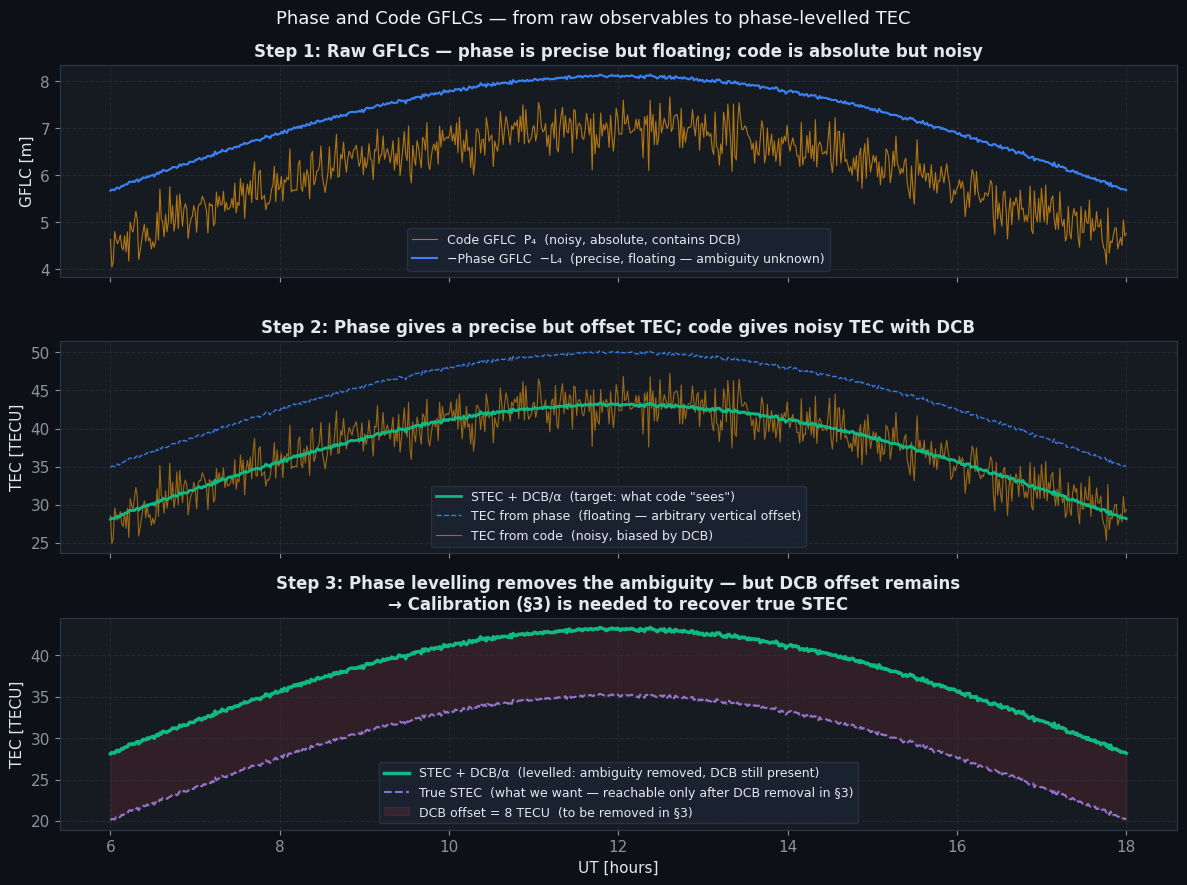

In [25]:
# ── Figure 2: Phase vs Code GFLC — phase levelling ───────────────────────────
# This figure illustrates three steps toward phase-levelled TEC.
# IMPORTANT: "tec_levelled" below is NOT calibrated TEC — it is the
# phase-levelled observable, still biased by DCBs (B_sat + B_rec).
# The green curve labelled "STEC (no ambiguity, with DCB)" represents
# the idealised levelled observable; calibration (§3) is still needed
# to remove the DCB offset.

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
t_pass = np.linspace(6, 18, 720)

# Simulate a smooth STEC arc (still contains DCB — not "true" absolute TEC)
stec_no_ambiguity = 20 + 15 * np.sin(np.pi * (t_pass - 6) / 12)  # TECU
# DCB offset (what separates levelled TEC from calibrated TEC)
dcb_offset = 8.0   # TECU — typical combined sat+rec DCB

f1 = 1575.42e6
alpha = 40.3e16 / f1**2   # m/TECU

# Phase GFLC: precise but floating (ambiguity + IFB offset)
phase_noise = np.random.normal(0, 0.02, len(t_pass))
arc_bias = alpha * (stec_no_ambiguity[0] - 5)   # arbitrary ambiguity offset in metres
phase_gflc = -alpha * stec_no_ambiguity - arc_bias + phase_noise

# Code GFLC: noisy + DCB (absolute but biased by DCB)
code_noise = np.random.normal(0, 0.3, len(t_pass))
code_gflc = alpha * stec_no_ambiguity + alpha * dcb_offset + code_noise

# TEC from phase (floating — ambiguity unknown, no DCB)
tec_phase_raw = -phase_gflc / alpha

# Phase-levelled TEC: ambiguity removed, but DCB still present
amb_est = np.mean(code_gflc + phase_gflc)
tec_levelled = (-phase_gflc + amb_est) / alpha   # ≈ STEC + DCB/alpha

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle('Phase and Code GFLCs — from raw observables to phase-levelled TEC',
             color='#f0f6ff', fontsize=13)

# Step 1: raw GFLCs
axes[0].plot(t_pass, code_gflc, color='#f59e0b', lw=0.8, alpha=0.7,
             label='Code GFLC  P₄  (noisy, absolute, contains DCB)')
axes[0].plot(t_pass, -phase_gflc, color='#3b82f6', lw=1.5,
             label='−Phase GFLC  −L₄  (precise, floating — ambiguity unknown)')
axes[0].set_ylabel('GFLC [m]')
axes[0].legend(fontsize=9)
axes[0].grid(True)
axes[0].set_title('Step 1: Raw GFLCs — phase is precise but floating; code is absolute but noisy')

# Step 2: TEC extracted, before levelling
axes[1].plot(t_pass, tec_levelled, color='#10b981', lw=2,
             label='STEC + DCB/α  (target: what code "sees")', zorder=3)
axes[1].plot(t_pass, tec_phase_raw, color='#3b82f6', lw=1, alpha=0.9,
             label='TEC from phase  (floating — arbitrary vertical offset)', ls='--')
axes[1].plot(t_pass, code_gflc / alpha, color='#f59e0b', lw=0.8, alpha=0.6,
             label='TEC from code  (noisy, biased by DCB)')
axes[1].set_ylabel('TEC [TECU]')
axes[1].legend(fontsize=9)
axes[1].grid(True)
axes[1].set_title('Step 2: Phase gives a precise but offset TEC; code gives noisy TEC with DCB')

# Step 3: phase levelled — ambiguity removed, DCB still present
axes[2].plot(t_pass, tec_levelled, color='#10b981', lw=2.5, zorder=3,
             label='STEC + DCB/α  (levelled: ambiguity removed, DCB still present)')
axes[2].plot(t_pass, tec_levelled - dcb_offset, color='#a78bfa', lw=1.5,
             ls='--', alpha=0.8,
             label='True STEC  (what we want — reachable only after DCB removal in §3)')
axes[2].fill_between(t_pass, tec_levelled, tec_levelled - dcb_offset,
                     alpha=0.12, color='#ef4444',
                     label=f'DCB offset = {dcb_offset:.0f} TECU  (to be removed in §3)')
axes[2].set_ylabel('TEC [TECU]')
axes[2].set_xlabel('UT [hours]')
axes[2].legend(fontsize=9)
axes[2].grid(True)
axes[2].set_title(
    'Step 3: Phase levelling removes the ambiguity — but DCB offset remains\n'
    '→ Calibration (§3) is needed to recover true STEC')

plt.tight_layout()
plt.savefig('fig2_phase_code.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()


### <span style="color:#fbbf24">2.4 From Slant TEC to Vertical TEC</span>

The GFLC gives <span style="color:#a78bfa">**STEC**</span> along the actual signal path.  
We project to <span style="color:#34d399">**VTEC**</span> using the **thin-shell mapping function** $M(\varepsilon)$:

$$\boxed{\text{STEC} = \text{VTEC} \times M(\varepsilon)}$$

$$M(\varepsilon) = \frac{1}{\cos\chi'}, \qquad \sin\chi' = \frac{R_E}{R_E + H}\cos\varepsilon$$

where:
- $\color{#a78bfa}{\varepsilon}$ = satellite elevation angle
- $\color{#a78bfa}{\chi'}$ = zenith angle at the **Ionospheric Pierce Point (IPP)**
- $\color{#fbbf24}{H \approx 350}$<span style="color:#fbbf24"> km</span> = assumed thin-shell height
- $\color{#fbbf24}{R_E = 6371}$<span style="color:#fbbf24"> km</span> = Earth radius

The **IPP** is the intersection of the satellite–receiver ray with the thin shell — it is the geographic location assigned to each STEC measurement.

> <span style="color:#f87171">⚠️ Low-elevation satellites (</span>$\color{#f87171}{\varepsilon < 20°}$<span style="color:#f87171">) have large </span>$\color{#f87171}{M}$<span style="color:#f87171"> values, amplifying noise and multipath → typically masked out by the **elevation cut-off** (20° in the Gg software).</span>


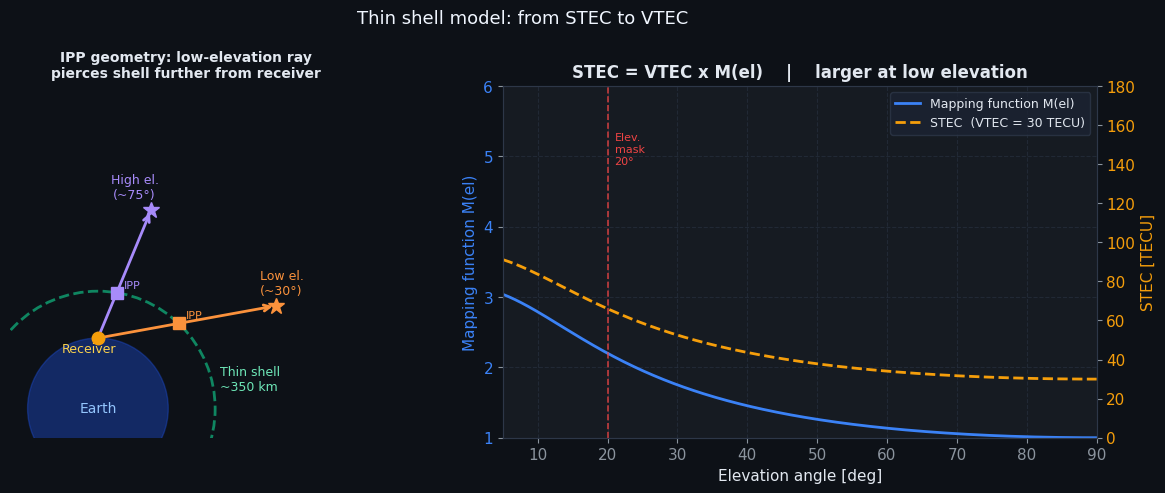

Figure 3: left = IPP geometry | right = mapping function M(el) vs elevation


In [26]:
# ── Figure 3: Thin-shell geometry and mapping function ───────────────────────
# LEFT  — IPP geometry for a high- and a low-elevation satellite. The
#          low-elevation ray path (orange) crosses the shell at a larger
#          zenith angle, placing the IPP further from the receiver.
# RIGHT — Mapping function M(el) [left axis, blue] and resulting STEC
#          [right axis, orange] for a fixed VTEC of 30 TECU. The elevation
#          mask at 20° (red dashed) cuts off the noisiest measurements.

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Thin shell model: from STEC to VTEC', color='#f0f6ff', fontsize=13)

# ── LEFT: IPP geometry diagram ─────────────────────────────────────────────────
ax = axes[0]
ax.set_xlim(-1.5, 4.5)
ax.set_ylim(-0.5, 5.5)
ax.set_aspect('equal')
ax.axis('off')

earth = plt.Circle((0, 0), 1.2, color='#1d4ed8', alpha=0.4, zorder=1)
ax.add_patch(earth)
ax.text(0, 0, 'Earth', ha='center', va='center', color='#93c5fd', fontsize=10)

shell = plt.Circle((0, 0), 2.0, color='#10b981', fill=False, lw=2,
                   ls='--', alpha=0.7, zorder=2)
ax.add_patch(shell)
ax.text(2.08, 0.3, 'Thin shell\n~350 km', color='#6ee7b7', fontsize=9)

rx = np.array([0.0, 1.2])
ax.plot(*rx, 'o', color='#f59e0b', ms=9, zorder=7)
ax.text(rx[0]-0.15, rx[1]-0.25, 'Receiver', color='#fcd34d', fontsize=9, ha='center')

for angle, label, col, sat_dist, lx, ly in [
        (75, 'High el.\n(~75°)', '#a78bfa', 3.5, -0.28,  0.15),
        (30, 'Low el.\n(~30°)',  '#fb923c', 3.5,  0.10,  0.15)]:
    ang_r = np.radians(angle)
    sat = np.array([np.cos(ang_r), np.sin(ang_r)]) * sat_dist
    direction = (sat - rx) / np.linalg.norm(sat - rx)
    b = 2 * np.dot(rx, direction)
    c = np.dot(rx, rx) - 4.0
    t = (-b + np.sqrt(b**2 - 4*c)) / 2
    ipp = rx + t * direction

    ax.annotate('', xy=sat, xytext=rx,
                arrowprops=dict(arrowstyle='->', color=col, lw=2.0), zorder=5)
    ax.plot(*ipp, 's', color=col, ms=8, zorder=8)
    ax.text(ipp[0]+0.12, ipp[1]+0.08, 'IPP', color=col, fontsize=8)
    ax.plot(*sat, '*', color=col, ms=12, zorder=8)
    ax.text(sat[0]+lx, sat[1]+ly, label, color=col, fontsize=9,
            ha='center', va='bottom')

ax.set_title('IPP geometry: low-elevation ray\npierces shell further from receiver',
             color='#e2e8f0', fontsize=10)

# ── RIGHT: mapping function (dual y-axis) ──────────────────────────────────────
ax2 = axes[1]
elev = np.linspace(5, 90, 300)
Re, H = 6371.0, 350.0
chi_prime = np.arcsin((Re / (Re + H)) * np.cos(np.radians(elev)))
mf = 1.0 / np.cos(chi_prime)
vtec_example = 30.0
stec = vtec_example * mf

l1, = ax2.plot(elev, mf, color='#3b82f6', lw=2, label='Mapping function M(el)')
ax2.set_xlabel('Elevation angle [deg]')
ax2.set_ylabel('Mapping function M(el)', color='#3b82f6')
ax2.tick_params(axis='y', labelcolor='#3b82f6')
ax2.set_xlim(5, 90)
ax2.set_ylim(1, 6)
ax2.grid(True)

ax2r = ax2.twinx()
ax2r.set_facecolor('none')
l2, = ax2r.plot(elev, stec, color='#f59e0b', lw=2, ls='--',
                label=f'STEC  (VTEC = {vtec_example:.0f} TECU)')
ax2r.axvline(20, color='#ef4444', lw=1.2, ls='--', alpha=0.8)
ax2r.text(21, 140, 'Elev.\nmask\n20°', color='#ef4444', fontsize=8)
ax2r.set_ylabel('STEC [TECU]', color='#f59e0b')
ax2r.tick_params(axis='y', labelcolor='#f59e0b')
ax2r.set_ylim(0, 180)

ax2.legend([l1, l2], [l1.get_label(), l2.get_label()], fontsize=9, loc='upper right')
ax2.set_title('STEC = VTEC x M(el)    |    larger at low elevation')

plt.tight_layout()
plt.savefig('fig3_thin_shell.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Figure 3: left = IPP geometry | right = mapping function M(el) vs elevation")


---
## <span style="color:#2dd4bf">Biases and the Gg Calibration Technique</span>

### <span style="color:#fbbf24">3.1 Hardware biases (DCBs)</span>

Both satellite and receiver hardware introduce **frequency-dependent delays** in the code observable:

$$\underbrace{B_{\text{DCB}}}_{\text{total}} = \underbrace{B^{\text{sat}}_{i} - B^{\text{sat}}_{j}}_{\text{satellite DCB}} + \underbrace{B^{\text{rec}}_{i} - B^{\text{rec}}_{j}}_{\text{receiver DCB}}$$

| Property | Value |
|---|---|
| Typical magnitude | <span style="color:#f87171">**5–20 ns → 1.5–6 m → 10–40 TECU at L1/L2**</span> |
| Stability | Quasi-constant over days, slow drift |
| Sign convention | Affects $P_4$ but **not** $L_4$ directly |

> <span style="color:#f87171">⚠️ Without DCB removal, TEC estimates are biased by tens of TECU — comparable to the ionospheric signal itself during quiet conditions.</span>

---

### <span style="color:#fbbf24">3.2 The Gg technique (Ciraolo / Cesaroni)</span>

The Gg method solves jointly for:

1. <span style="color:#a78bfa">**VTEC polynomial** in Local Time (LT) and MODIP latitude </span>$\color{#a78bfa}{\mu}$  
2. <span style="color:#fbbf24">**Arc biases** (phase ambiguity + IFB residuals)</span>  
3. <span style="color:#34d399">**Receiver DCB** </span>$\color{#34d399}{B^{\text{rec}}}$

**VTEC expansion:**

$$\text{VTEC}(\mu, \text{LT}) = \sum_{m,n} c_{mn} \cdot \text{LT}^m \cdot P_n(\mu)$$

where $\color{#fbbf24}{\mu}$<span style="color:#fbbf24"> = MODIP latitude</span> (Modified Dip latitude — aligns with the magnetic equator, making the EIA symmetric).

**Why MODIP?**  
The Equatorial Ionization Anomaly (EIA) is symmetric in MODIP but **asymmetric in geographic latitude** (magnetic equator ≠ geographic equator).

**Windowed least squares:**  
The day is divided into <span style="color:#a78bfa">**96 windows of 15 minutes**</span> each (~30 observations per window).  
Within each window, VTEC polynomial coefficients are held **constant**, and the system is solved for $c_{mn}$ + all arc biases simultaneously.


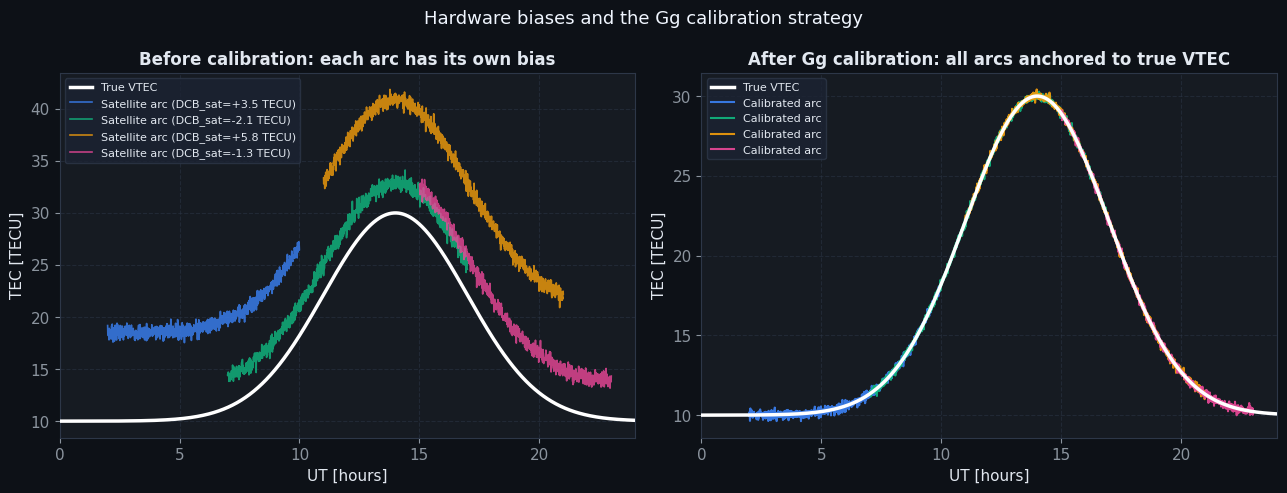

In [27]:
# ── Figure 4: DCB impact and the calibration concept ────────────────────────
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)
t = np.linspace(0, 24, 2880)
# "True" VTEC diurnal cycle
vtec_true = 10 + 20 * np.exp(-0.5 * ((t - 14) / 3)**2)

# Multiple satellite arcs (simplified: 4 arcs)
arcs = [
    (2, 10, 3.5, '#3b82f6'),
    (7, 17, -2.1, '#10b981'),
    (11, 21, 5.8, '#f59e0b'),
    (15, 23, -1.3, '#ec4899'),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Hardware biases and the Gg calibration strategy',
             color='#f0f6ff', fontsize=13)

# Left: biased arcs
ax = axes[0]
ax.plot(t, vtec_true, 'w-', lw=2.5, label='True VTEC', zorder=5)
total_bias = 5.0   # receiver DCB in TECU
for t0, t1, sat_dcb, col in arcs:
    mask = (t >= t0) & (t <= t1)
    ta = t[mask]
    va = vtec_true[mask] + total_bias + sat_dcb
    noise = np.random.normal(0, 0.4, len(ta))
    ax.plot(ta, va + noise, color=col, lw=1.2, alpha=0.8,
            label=f'Satellite arc (DCB_sat={sat_dcb:+.1f} TECU)')
ax.set_xlabel('UT [hours]')
ax.set_ylabel('TEC [TECU]')
ax.set_title('Before calibration: each arc has its own bias')
ax.legend(fontsize=8, loc='upper left')
ax.grid(True)
ax.set_xlim(0, 24)

# Right: after Gg calibration
ax2 = axes[1]
ax2.plot(t, vtec_true, 'w-', lw=2.5, label='True VTEC', zorder=5)
for t0, t1, sat_dcb, col in arcs:
    mask = (t >= t0) & (t <= t1)
    ta = t[mask]
    va = vtec_true[mask]
    noise = np.random.normal(0, 0.15, len(ta))
    ax2.plot(ta, va + noise, color=col, lw=1.5, alpha=0.9,
             label=f'Calibrated arc')
ax2.set_xlabel('UT [hours]')
ax2.set_ylabel('TEC [TECU]')
ax2.set_title('After Gg calibration: all arcs anchored to true VTEC')
ax2.legend(fontsize=8, loc='upper left')
ax2.grid(True)
ax2.set_xlim(0, 24)

plt.tight_layout()
plt.savefig('fig4_dcb_calibration.png', dpi=120, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()

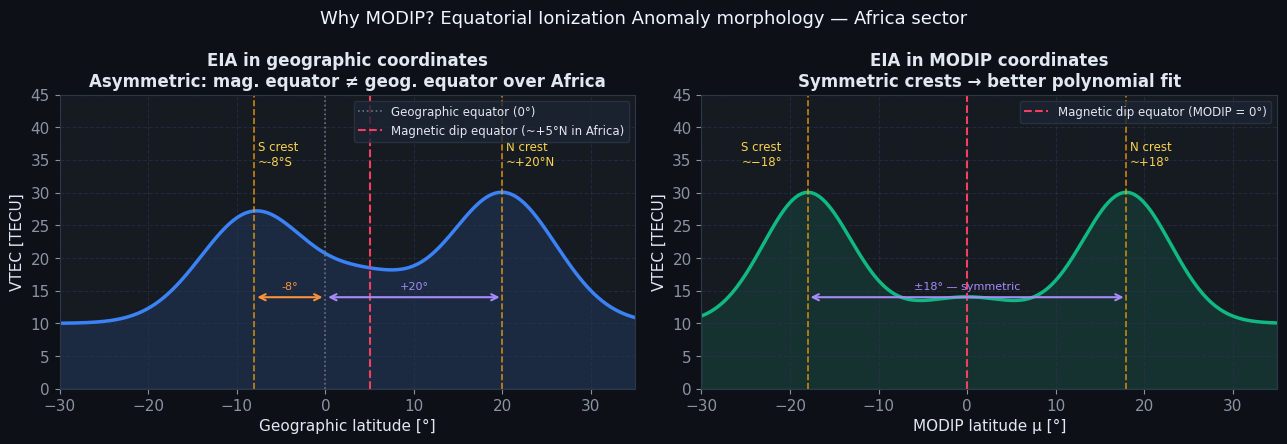

In [28]:
# ── Figure 5: EIA morphology — geographic vs MODIP ───────────────────────────
# LEFT  — EIA in geographic coordinates over the Africa sector (~15°E longitude).
#          The magnetic dip equator is ~+5°N of the geographic equator in Africa,
#          so the EIA crests are ASYMMETRIC in geographic coordinates:
#          northern crest ~+20°N geographic, southern crest ~-8°S geographic.
#          A polynomial in geographic latitude fits this poorly.
# RIGHT — The same EIA in MODIP coordinates: both crests appear at ±18° MODIP,
#          perfectly symmetric around the magnetic equator → ideal for a
#          polynomial expansion (Gg technique).

import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle('Why MODIP? Equatorial Ionization Anomaly morphology — Africa sector',
             color='#f0f6ff', fontsize=13)

lat_geo   = np.linspace(-30, 35, 400)
lat_modip = np.linspace(-30, 35, 400)

# Magnetic dip equator offset in Africa sector (~15°E): +5°N geographic
mag_eq_offset = 5.0

def eia_geo(lat):
    lr = lat - mag_eq_offset   # latitude relative to magnetic equator
    return (10 +
            20 * np.exp(-0.5 * ((lr - 15) / 6)**2) +   # N crest ~+20°N geo
            17 * np.exp(-0.5 * ((lr + 13) / 6)**2) +   # S crest ~-8°S geo (weaker)
             6 * np.exp(-0.5 * (lr / 5)**2))            # trough at mag. equator

def eia_modip(mu):
    return (10 +
            20 * np.exp(-0.5 * ((mu - 18) / 5)**2) +
            20 * np.exp(-0.5 * ((mu + 18) / 5)**2) +
             4 * np.exp(-0.5 * (mu / 6)**2))

# ── LEFT: geographic — asymmetric ─────────────────────────────────────────────
ax = axes[0]
vtec_geo = eia_geo(lat_geo)
ax.plot(lat_geo, vtec_geo, color='#3b82f6', lw=2.5)
ax.fill_between(lat_geo, vtec_geo, alpha=0.15, color='#3b82f6')

ax.axvline(0, color='#6b7280', lw=1.2, ls=':', label='Geographic equator (0°)')
ax.axvline(mag_eq_offset, color='#f43f5e', lw=1.5, ls='--',
           label=f'Magnetic dip equator (~+{mag_eq_offset:.0f}°N in Africa)')

n_crest_geo = mag_eq_offset + 15    # ~+20°N geographic
s_crest_geo = mag_eq_offset - 13    # ~-8°S geographic
for xc, lbl in [(n_crest_geo, f'N crest\n~+{n_crest_geo:.0f}°N'),
                (s_crest_geo, f'S crest\n~{s_crest_geo:.0f}°S')]:
    ax.axvline(xc, color='#f59e0b', lw=1.2, ls='--', alpha=0.8)
    ax.text(xc + 0.4, 38, lbl, color='#fcd34d', fontsize=8.5, va='top')

# Arrows showing asymmetric distances from geographic equator
ax.annotate('', xy=(n_crest_geo, 14), xytext=(0, 14),
            arrowprops=dict(arrowstyle='<->', color='#a78bfa', lw=1.5))
ax.text(n_crest_geo/2, 15.2, f'+{n_crest_geo:.0f}°',
        color='#a78bfa', fontsize=8, ha='center')
ax.annotate('', xy=(s_crest_geo, 14), xytext=(0, 14),
            arrowprops=dict(arrowstyle='<->', color='#fb923c', lw=1.5))
ax.text(s_crest_geo/2, 15.2, f'{s_crest_geo:.0f}°',
        color='#fb923c', fontsize=8, ha='center')

ax.set_xlabel('Geographic latitude [°]')
ax.set_ylabel('VTEC [TECU]')
ax.set_title('EIA in geographic coordinates\n'
             'Asymmetric: mag. equator ≠ geog. equator over Africa')
ax.legend(fontsize=8.5, loc='upper right')
ax.set_xlim(-30, 35)
ax.set_ylim(0, 45)
ax.grid(True)

# ── RIGHT: MODIP — symmetric ───────────────────────────────────────────────────
ax2 = axes[1]
vtec_mod = eia_modip(lat_modip)
ax2.plot(lat_modip, vtec_mod, color='#10b981', lw=2.5)
ax2.fill_between(lat_modip, vtec_mod, alpha=0.15, color='#10b981')

ax2.axvline(0, color='#f43f5e', lw=1.5, ls='--',
            label='Magnetic dip equator (MODIP = 0°)')

for xc, lbl in [(-18, 'S crest\n~−18°'), (+18, 'N crest\n~+18°')]:
    ax2.axvline(xc, color='#f59e0b', lw=1.2, ls='--', alpha=0.8)
    ax2.text(xc + 0.4 if xc > 0 else xc - 7.5, 38, lbl,
             color='#fcd34d', fontsize=8.5, va='top')

ax2.annotate('', xy=(18, 14), xytext=(-18, 14),
             arrowprops=dict(arrowstyle='<->', color='#a78bfa', lw=1.5))
ax2.text(0, 15.2, '±18° — symmetric', color='#a78bfa',
         fontsize=8, ha='center')

ax2.set_xlabel('MODIP latitude μ [°]')
ax2.set_ylabel('VTEC [TECU]')
ax2.set_title('EIA in MODIP coordinates\n'
              'Symmetric crests → better polynomial fit')
ax2.legend(fontsize=8.5, loc='upper right')
ax2.set_xlim(-30, 35)
ax2.set_ylim(0, 45)
ax2.grid(True)

plt.tight_layout()
plt.savefig('fig5_modip_eia.png', dpi=120, bbox_inches='tight', facecolor='#0d1117')
plt.show()


### 3.3 The Gg calibration algorithm — step by step

1. **Read** observation (`.yyo`) and navigation (`.yyn`/`.yyg`) RINEX files
2. **Compute** GFLC from phase ($L_4$) and code ($P_4$) measurements at all epochs
3. **Detect cycle slips** and number the arcs
4. **Phase levelling** — estimate arc ambiguity $\hat{B}_\phi$ from $\langle P_4 - L_4 \rangle_{\text{arc}}$
5. **Map** STEC → VTEC at each IPP using the thin-shell mapping function
6. **Divide the day** into 15-minute windows (96 total, ~30 observations each)
7. **Solve jointly** for VTEC polynomial coefficients $c_{mn}$ and arc biases using least squares
8. **Output** calibrated STEC and VTEC, IPP coordinates, elevation, azimuth

### 3.4 References

- Ciraolo L., Azpilicueta F., Brunini C., Meza A., Radicella S.M. (2007).
  Calibration errors on experimental slant total electron content (TEC) determined with GPS.
  *Journal of Geodesy*, **81**(2), 111–120.
  DOI: [10.1007/s00190-006-0093-1](https://doi.org/10.1007/s00190-006-0093-1)

- Cesaroni C., Spogli L., Alfonsi L., De Franceschi G., Ciraolo L., Galera Monico J.F.,
  Scotto C., Romano V., Aquino M., Bougard B. (2015).
  L-band scintillations and calibrated total electron content gradients over Brazil
  during the last solar maximum.
  *Journal of Space Weather and Space Climate*, **5**, A36.
  DOI: [10.1051/swsc/2015038](https://doi.org/10.1051/swsc/2015038)

- Cesaroni C., Spogli L., De Franceschi G. (2021).
  IONORING: Real-Time Monitoring of the Total Electron Content over Italy.
  *Remote Sensing*, **13**(16), 3290.
  DOI: [10.3390/rs13163290](https://doi.org/10.3390/rs13163290)

- Ventriglia V., Guerra M., Okoh D., Vermicelli P., Ciraolo L., Cesaroni C. (2026).
  PyTECGg: Total Electron Content reconstruction with GNSS data.
  *SoftwareX* (in press; preprint available on SSRN, April 2026).
  DOI: [10.2139/ssrn.5215848](https://doi.org/10.2139/ssrn.5215848)


---
## PyTECGg in Practice

**PyTECGg** is an open-source Python package (Rust core) implementing the Gg calibration algorithm.

- 📦 Install: `pip install pytecgg`
- ⭐ GitHub: [github.com/viventriglia/PyTECGg](https://github.com/viventriglia/PyTECGg)
- 📄 Reference: Ventriglia et al. (2026), *SoftwareX*

Supports RINEX v2/v3/v4, GPS, Galileo, GLONASS, BeiDou.  
Blazing-fast reading (≲ 1 s per file). pip-installable — no Rust toolchain needed.


In [29]:
# ── Step 1: Install PyTECGg ─────────────────────────────────────────────────
# Run this cell first in your Colab environment
!pip install pytecgg


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
# ── Step 2: Setup directories and download RINEX data ───────────────────────
import os
import pytecgg
from pytecgg.utils import download_obs_euref, download_nav_bkg
from pathlib import Path # Import Path from pathlib

# Directory setup
input_obs_dir = Path("rinex/obs") # Changed to Path object
input_nav_dir = Path("rinex/nav") # Changed to Path object
output_dir    = "results"

for d in [input_obs_dir, input_nav_dir, Path(output_dir)]:
    os.makedirs(d, exist_ok=True)

# ── Data parameters — change these! ─────────────────────────────────────────
station = "MATE"   # EUREF station code (4 chars uppercase)
year    = 2023
doy     = 150      # Day Of Year (1–365)

print(f"Downloading RINEX obs for {station}, year {year}, DOY {doy} ...")
try:
    download_obs_euref(
        station_code=station,
        year=year,
        doys=[doy],
        output_path=input_obs_dir # Now a Path object
    )
    print("✓ Observation file download complete")
except Exception as e:
    print(f"✗ Error: {e}")

print("\nDownloading broadcast navigation file from BKG ...")
try:
    download_nav_bkg(
        year=year,
        doys=[doy],
        output_path=input_nav_dir # Now a Path object
    )
    print("✓ Navigation file download complete")
except Exception as e:
    print(f"✗ Error: {e}")

✓ Observation file download complete

✓ Navigation file download complete


In [ ]:
# ── Step 3: Inspect downloaded RINEX files ───────────────────────────────────
# Shows: list of downloaded files with sizes

from pathlib import Path

input_obs_dir = Path(input_obs_dir)
input_nav_dir = Path(input_nav_dir)

obs_files = sorted([f for f in input_obs_dir.rglob("*") if f.is_file()])
nav_files = sorted([f for f in input_nav_dir.rglob("*") if f.is_file()])

print("=== Downloaded files ===")
for f in obs_files + nav_files:
    print(f"  {f.name}  ({f.stat().st_size/1024:.0f} kB)")


In [32]:
# ── Step 4: Run TEC calibration with PyTECGg ────────────────────────────────
#
# Full Gg calibration pipeline. Run AFTER Steps 1–3.
#
# Bugs fixed vs. original version:
#   1. File detection used rglob("*") which returned directories too → Rust
#      panic. Fixed: filter with f.is_file().
#   2. prepare_ephemeris() must be called BEFORE calculate_linear_combinations()
#      because it populates ctx.glonass_channels (needed for GLONASS GFLC).
#   3. calculate_linear_combinations() needs "mw" (Melbourne-Wübbena) in the
#      combinations list — extract_arcs() uses it for cycle-slip detection.
#   4. The arc column is named "id_arc_valid", not "arc_id".
#   5. calculate_tec() already produces both "stec" and "vtec" per satellite.
#      calculate_vertical_equivalent() adds "veq" (single zenithal value per
#      epoch, useful for time-series comparison).

from pathlib import Path
import polars as pl

from pytecgg import GNSSContext
from pytecgg.parsing import read_rinex_obs, read_rinex_nav
from pytecgg.linear_combinations.lc_calculation import calculate_linear_combinations
from pytecgg.satellites.ephemeris import prepare_ephemeris
from pytecgg.satellites.positions import satellite_coordinates
from pytecgg.satellites.ipp import calculate_ipp
from pytecgg.tec_calibration.arcs import extract_arcs
from pytecgg.tec_calibration.calibration import calculate_tec, calculate_vertical_equivalent

# ── 4.1  Locate RINEX files for the station/year/doy set in Step 2 ───────────
# download_obs_euref() saves obs files under a per-station subfolder, so filter
# on that; nav files are shared across stations, so filter on year/doy instead.
obs_dir = Path(input_obs_dir) / station.upper()
obs_files = sorted([f for f in obs_dir.rglob("*") if f.is_file()])

yeardoy = f"{year}{doy:03d}"
nav_files = sorted([f for f in Path(input_nav_dir).rglob("*")
                    if f.is_file() and yeardoy in f.name])

if not obs_files:
    raise FileNotFoundError(f"No observation file for station {station} in {obs_dir}. Run Step 2 first.")
if not nav_files:
    raise FileNotFoundError(f"No navigation file for {year} DOY {doy:03d} in {input_nav_dir}. Run Step 2 first.")

obs_path, nav_path = obs_files[0], nav_files[0]
print(f"Obs : {obs_path}")
print(f"Nav : {nav_path}")

# ── 4.2  Read RINEX files ─────────────────────────────────────────────────────
print("\nReading RINEX files ...")
obs_data, receiver_pos_ecef, rinex_version = read_rinex_obs(obs_path)
nav_data = read_rinex_nav(nav_path)
print(f"  Obs  : {obs_data.shape[0]:,} rows | {obs_data.shape[1]} columns | RINEX {rinex_version}")
print(f"  ECEF : {[f'{v:.3f}' for v in receiver_pos_ecef]} m")
print(f"  Nav  : constellations {list(nav_data.keys())}")

# ── 4.3  Build GNSSContext ────────────────────────────────────────────────────
available_systems = [s for s in ["GPS", "GLONASS", "GALILEO"]
                     if any(s[0] in k for k in nav_data.keys())]

ctx = GNSSContext(
    receiver_pos  = receiver_pos_ecef,
    receiver_name = station,
    rinex_version = rinex_version,
    h_ipp         = 350_000,           # thin shell height in metres (350 km)
    systems       = available_systems,
)
print(f"\nContext: station={station}, systems={ctx.systems}, h_ipp={ctx.h_ipp/1000:.0f} km")

# ── 4.4  Ephemeris — MUST come before calculate_linear_combinations ───────────
# prepare_ephemeris() populates ctx.glonass_channels, which is required
# when GLONASS is in the constellation list.
print("\nPreparing ephemeris ...")
ephem_dict = prepare_ephemeris(nav_data, ctx)
print(f"  {len(ephem_dict)} satellites in ephemeris")

# ── 4.5  Geometry-Free Linear Combinations ───────────────────────────────────
# "mw" (Melbourne-Wübbena) MUST be included: extract_arcs() uses it
# for cycle-slip and loss-of-lock detection.
print("\nComputing linear combinations (GFLC phase, GFLC code, MW) ...")
lc_data = calculate_linear_combinations(
    obs_data       = obs_data,
    ctx            = ctx,
    combinations   = ["gflc_phase", "gflc_code", "mw"],
    selection_mode = "quality",
)
print(f"  {lc_data.shape[0]:,} observations | columns: {lc_data.columns}")

# ── 4.6  Satellite positions and IPP coordinates ──────────────────────────────
print("\nComputing satellite positions and IPP coordinates ...")
sat_coords = satellite_coordinates(
    sv_ids=lc_data["sv"], epochs=lc_data["epoch"], ephem_dict=ephem_dict)
lc_data = lc_data.join(sat_coords, on=["sv", "epoch"], how="left")
lc_data = calculate_ipp(df=lc_data, ctx=ctx, min_elevation=20.0)
print(f"  {lc_data.shape[0]:,} observations after elevation mask (20°)")
print(f"  IPP columns added: lat_ipp, lon_ipp, azi, ele")

# ── 4.7  Arc extraction (cycle-slip / loss-of-lock detection) ─────────────────
print("\nExtracting continuous arcs ...")
lc_data = extract_arcs(
    df             = lc_data,
    ctx            = ctx,
    threshold_abs  = 5.0,
    threshold_std  = 5.0,
    min_arc_length = 30,
    threshold_jump = 10.0,
)
# Note: arc column is "id_arc_valid" (not "arc_id")
n_arcs = lc_data["id_arc_valid"].n_unique()
print(f"  {n_arcs} valid arcs found")
print(lc_data
      .group_by("sv")
      .agg(pl.col("id_arc_valid").n_unique().alias("n_arcs"))
      .sort("sv").head(8))

# ── 4.8  TEC calibration — Gg technique ─────────────────────────────────────
# Jointly estimates VTEC polynomial (MODIP + LT) and per-arc biases.
# Output columns added: bias, stec [TECU], vtec [TECU]
print("\nRunning Gg TEC calibration ...")
df_calibrated = calculate_tec(
    df                    = lc_data,
    ctx                   = ctx,
    max_polynomial_degree = 3,
    batch_size_epochs     = 30,
)
print(f"  Calibration done. New columns: bias, stec, vtec")

# ── 4.9  Vertical Equivalent (zenithal VEq per epoch) ────────────────────────
# calculate_tec() already provides per-satellite vtec.
# calculate_vertical_equivalent() adds "veq": a single station-zenith TEC
# value per epoch, obtained by evaluating the polynomial at zenith.
print("\nComputing zenithal vertical equivalent (veq) ...")
df_vtec = calculate_vertical_equivalent(
    df_calibrated         = df_calibrated,
    ctx                   = ctx,
    max_polynomial_degree = 3,
    batch_size_epochs     = 30,
)
print(f"  Final shape: {df_vtec.shape}")
print(df_vtec.select(["epoch", "sv", "lat_ipp", "lon_ipp", "ele", "stec", "vtec", "veq"]).head(5))

# ── 4.10  Save output ─────────────────────────────────────────────────────────
out_file = Path(output_dir) / f"{station}_{year}_{doy:03d}_vtec.csv"
df_vtec.write_csv(out_file)
print(f"\n✓ Output saved → {out_file}")
print(f"  {df_vtec.shape[0]:,} calibrated observations")
print("  Key output columns: epoch, sv, lat_ipp, lon_ipp, ele, stec, vtec, veq")


Obs : rinex\obs\2024_doy105\MATE\MATE00ITA_R_20241050000_01D_30S_MO.crx.gz
Nav : rinex\nav\2024_doy108\BRDC00IGS_R_20241080000_01D_MN.rnx.gz

Reading RINEX files ...
  Obs  : 1,540,091 rows | 4 columns | RINEX 3.4
  ECEF : ['4641949.814', '1393045.164', '4133287.281'] m
  Nav  : constellations ['BEIDOU', 'GALILEO', 'GLONASS', 'GPS']

Context: station=MATE, systems=['E', 'G', 'R'], h_ipp=350 km

Preparing ephemeris ...
  81 satellites in ephemeris

Computing linear combinations (GFLC phase, GFLC code, MW) ...
  74,288 observations | columns: ['epoch', 'sv', 'gflc_phase', 'gflc_code', 'mw']

Computing satellite positions and IPP coordinates ...


ℹ️  These may be missing from NAV file or the time gap may be too large.



  58,014 observations after elevation mask (20°)
  IPP columns added: lat_ipp, lon_ipp, azi, ele

Extracting continuous arcs ...
  126 valid arcs found
shape: (8, 2)
┌─────┬────────┐
│ sv  ┆ n_arcs │
│ --- ┆ ---    │
│ str ┆ u32    │
╞═════╪════════╡
│ E02 ┆ 1      │
│ E03 ┆ 2      │
│ E04 ┆ 1      │
│ E05 ┆ 1      │
│ E07 ┆ 2      │
│ E08 ┆ 2      │
│ E09 ┆ 1      │
│ E10 ┆ 1      │
└─────┴────────┘

Running Gg TEC calibration ...
  Calibration done. New columns: bias, stec, vtec

Computing zenithal vertical equivalent (veq) ...
  Final shape: (58014, 24)
shape: (5, 8)
┌─────────────────────┬─────┬───────────┬───────────┬───────────┬───────────┬───────────┬──────────┐
│ epoch               ┆ sv  ┆ lat_ipp   ┆ lon_ipp   ┆ ele       ┆ stec      ┆ vtec      ┆ veq      │
│ ---                 ┆ --- ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---       ┆ ---      │
│ datetime[μs, UTC]   ┆ str ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64       ┆ f64      │
╞══════════════════

Loaded 58,014 rows — valid VTEC: 34,580  |  SVs: 78


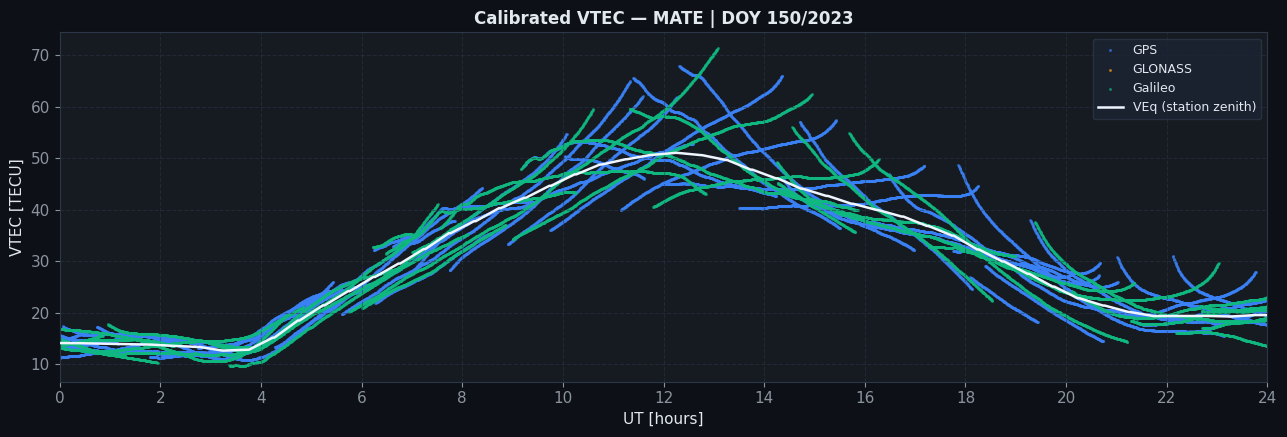

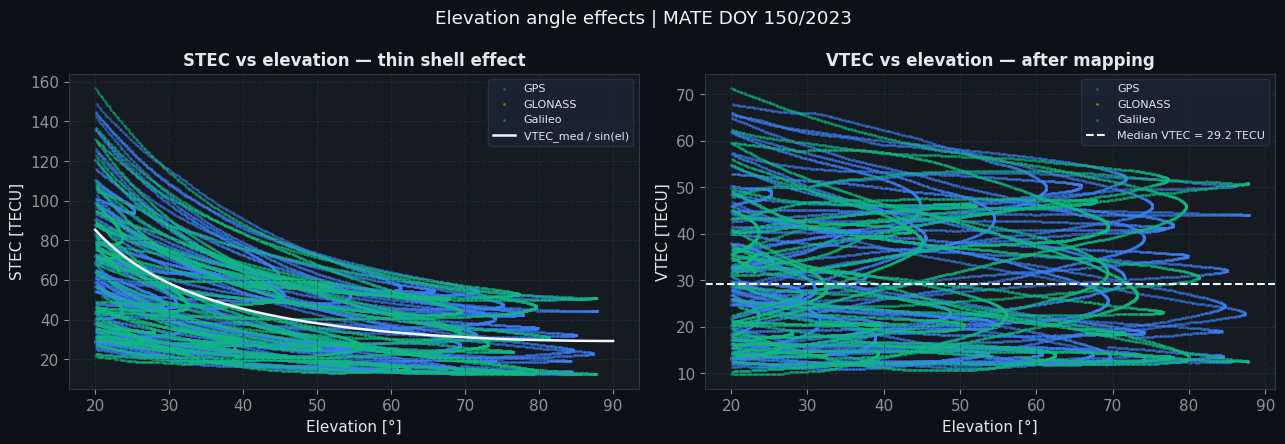

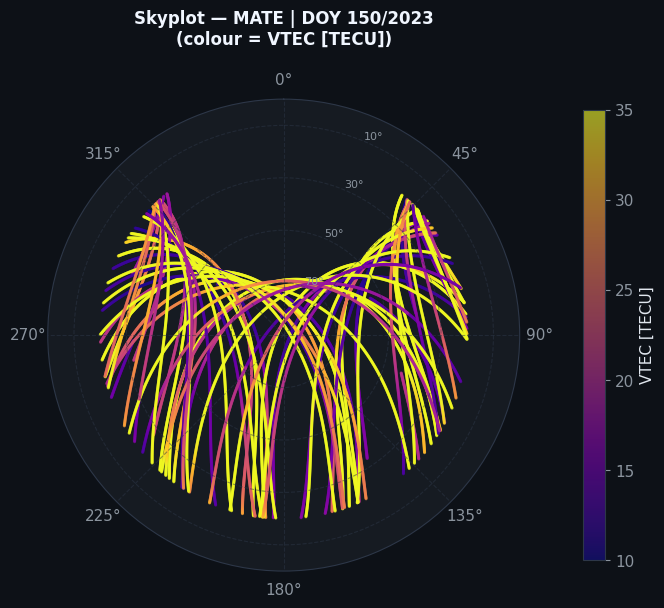

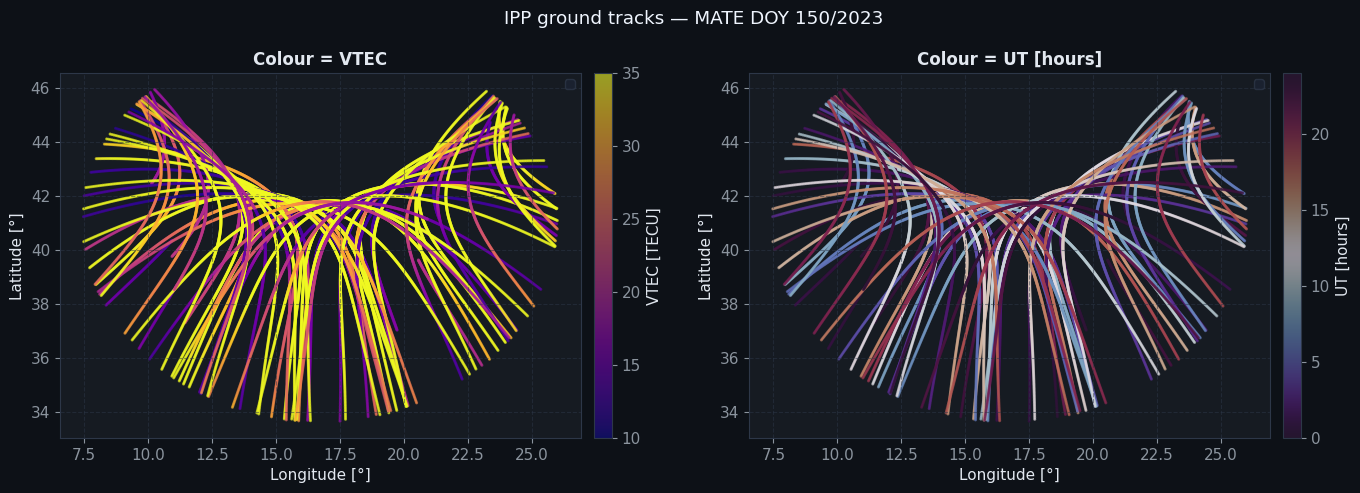

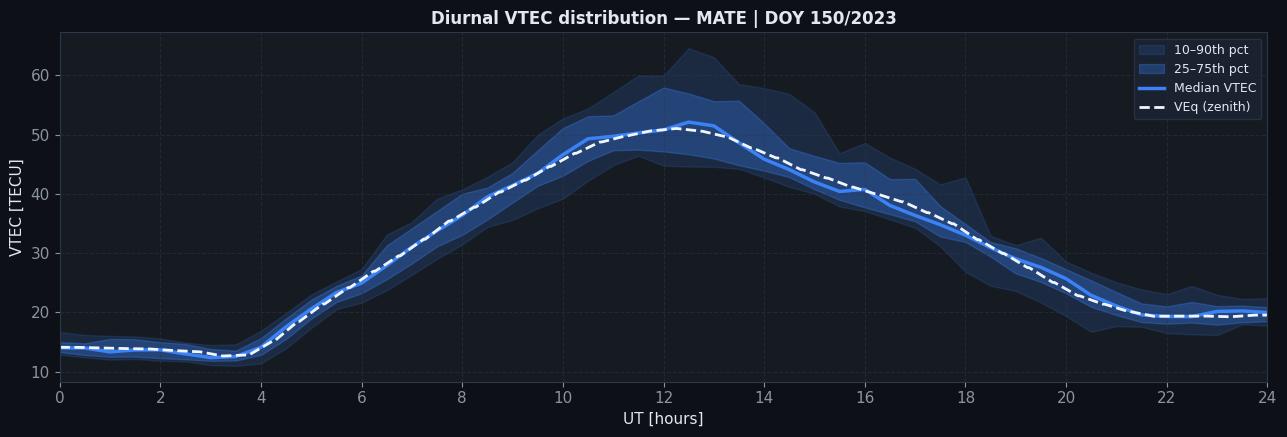


✓ All figures saved to results/


In [33]:
# ── Step 5: Visualise calibrated TEC ────────────────────────────────────────
# Produces 5 publication-quality figures from the CSV saved in Step 4.
# Run after Step 4 has completed successfully.

import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

# ── Load output CSV ───────────────────────────────────────────────────────────
out_file = Path(output_dir) / f"{station}_{year}_{doy:03d}_vtec.csv"
if not out_file.exists():
    raise FileNotFoundError(f"Output file not found: {out_file}. Run Step 4 first.")

df = pl.read_csv(out_file, try_parse_dates=True)
df = df.with_columns(
    (pl.col("epoch").dt.hour() + pl.col("epoch").dt.minute()/60 +
     pl.col("epoch").dt.second()/3600).alias("hour")
).to_pandas()

dfv = df[df["vtec"].notna()].copy()   # rows with valid VTEC
dfs = df[df["stec"].notna()].copy()   # rows with valid STEC
veq = df.drop_duplicates("epoch").sort_values("epoch")

print(f"Loaded {len(df):,} rows — valid VTEC: {len(dfv):,}  |  SVs: {df['sv'].nunique()}")

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':'#0d1117','axes.facecolor':'#161b22',
    'axes.edgecolor':'#2d3748','text.color':'#e2e8f0',
    'axes.labelcolor':'#e2e8f0','xtick.color':'#8b949e','ytick.color':'#8b949e',
    'grid.color':'#2d3748','grid.linestyle':'--','grid.alpha':0.5,
    'font.size':11,'axes.titlesize':12,'axes.titleweight':'bold',
    'legend.facecolor':'#1c2333','legend.edgecolor':'#2d3748'
})

CON_COLOR = {"G":"#3b82f6","R":"#f59e0b","E":"#10b981"}
CON_LABEL = {"G":"GPS","R":"GLONASS","E":"Galileo"}

# ─────────────────────────────────────────────────────────────────────────────
# Fig 1 — Calibrated VTEC vs UT, coloured by constellation + VEq overlay
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4.5))
for c, col in CON_COLOR.items():
    sub = dfv[dfv["sv"].str.startswith(c)]
    ax.scatter(sub["hour"], sub["vtec"], s=1.5, alpha=0.55, color=col,
               label=CON_LABEL[c], rasterized=True)
ax.plot(veq["hour"], veq["veq"], color="#f0f6ff", lw=1.8, zorder=5,
        label="VEq (station zenith)")
ax.set(xlabel="UT [hours]", ylabel="VTEC [TECU]",
       title=f"Calibrated VTEC — {station} | DOY {doy}/{year}",
       xlim=(0, 24))
ax.set_xticks(range(0, 25, 2))
ax.legend(fontsize=9, loc="upper right")
ax.grid(True)
plt.tight_layout()
plt.savefig(f"{output_dir}/fig1_vtec_vs_ut.png", dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 2 — STEC vs elevation (thin-shell effect) and VTEC vs elevation
# ─────────────────────────────────────────────────────────────────────────────
vtec_med = dfv["vtec"].median()
el_range = np.linspace(20, 90, 200)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle(f"Elevation angle effects | {station} DOY {doy}/{year}", color='#f0f6ff')
for c, col in CON_COLOR.items():
    sub = dfs[dfs["sv"].str.startswith(c)]
    axes[0].scatter(sub["ele"], sub["stec"], s=1.5, alpha=0.4, color=col,
                    label=CON_LABEL[c], rasterized=True)
    axes[1].scatter(sub["ele"], sub["vtec"], s=1.5, alpha=0.4, color=col,
                    label=CON_LABEL[c], rasterized=True)
axes[0].plot(el_range, vtec_med / np.sin(np.radians(el_range)), color="#f0f6ff",
             lw=1.8, label="VTEC_med / sin(el)", zorder=5)
axes[1].axhline(vtec_med, color="#f0f6ff", lw=1.5, ls="--",
                label=f"Median VTEC = {vtec_med:.1f} TECU")
for ax, ylabel, title in zip(axes,
    ["STEC [TECU]", "VTEC [TECU]"],
    ["STEC vs elevation — thin shell effect",
     "VTEC vs elevation — after mapping"]):
    ax.set(xlabel="Elevation [°]", ylabel=ylabel, title=title)
    ax.legend(fontsize=8); ax.grid(True)
plt.tight_layout()
plt.savefig(f"{output_dir}/fig2_stec_elevation.png", dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 3 — Skyplot: satellite tracks coloured by VTEC
# ─────────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(7, 7), facecolor='#0d1117')
ax = fig.add_subplot(111, projection='polar', facecolor='#161b22')
ax.set_theta_zero_location('N'); ax.set_theta_direction(-1)
ax.set_ylim(0, 90)
ax.set_yticks([20, 40, 60, 80])
ax.set_yticklabels(['70°','50°','30°','10°'], color='#8b949e', fontsize=8)
ax.tick_params(colors='#8b949e')
ax.grid(color='#2d3748', linestyle='--', alpha=0.5)
sc = ax.scatter(np.radians(dfs["azi"]), 90 - dfs["ele"],
                c=dfs["vtec"], cmap="plasma", s=1.5, alpha=0.6,
                vmin=10, vmax=35, rasterized=True)
cbar = plt.colorbar(sc, ax=ax, pad=0.1, shrink=0.7)
cbar.set_label("VTEC [TECU]", color='#e2e8f0')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#8b949e')
ax.set_title(f"Skyplot — {station} | DOY {doy}/{year}\n(colour = VTEC [TECU])",
             color='#f0f6ff', pad=20)
plt.tight_layout()
plt.savefig(f"{output_dir}/fig3_skyplot.png", dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 4 — IPP ground tracks: colour by VTEC (left) and UT (right)
# ─────────────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"IPP ground tracks — {station} DOY {doy}/{year}", color='#f0f6ff')
sc1 = axes[0].scatter(dfs["lon_ipp"], dfs["lat_ipp"], c=dfs["vtec"],
                      cmap="plasma", s=1.5, alpha=0.6, vmin=10, vmax=35, rasterized=True)
sc2 = axes[1].scatter(dfs["lon_ipp"], dfs["lat_ipp"], c=dfs["hour"],
                      cmap="twilight_shifted", s=1.5, alpha=0.6, vmin=0, vmax=24, rasterized=True)
for ax, sc, label, title in zip(axes, [sc1, sc2],
    ["VTEC [TECU]", "UT [hours]"],
    ["Colour = VTEC", "Colour = UT [hours]"]):
    ax.set(xlabel="Longitude [°]", ylabel="Latitude [°]", title=title)
    cb = plt.colorbar(sc, ax=ax, pad=0.02)
    cb.set_label(label, color='#e2e8f0')
    plt.setp(cb.ax.yaxis.get_ticklabels(), color='#8b949e')
    ax.legend(fontsize=9); ax.grid(True)
plt.tight_layout()
plt.savefig(f"{output_dir}/fig4_ipp_tracks.png", dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# ─────────────────────────────────────────────────────────────────────────────
# Fig 5 — Diurnal VTEC distribution (percentile ribbon) + VEq
# ─────────────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 4.5))
dfv2 = dfv.copy()
dfv2["hour_bin"] = (dfv2["hour"] * 2).round() / 2   # 30-min bins
grp = dfv2.groupby("hour_bin")["vtec"]
p10, p25 = grp.quantile(0.10), grp.quantile(0.25)
p50, p75, p90 = grp.quantile(0.50), grp.quantile(0.75), grp.quantile(0.90)
ax.fill_between(p50.index, p10, p90, alpha=0.15, color="#3b82f6", label="10–90th pct")
ax.fill_between(p50.index, p25, p75, alpha=0.30, color="#3b82f6", label="25–75th pct")
ax.plot(p50.index, p50, color="#3b82f6", lw=2.5, label="Median VTEC")
ax.plot(veq["hour"], veq["veq"], color="#f0f6ff", lw=2, ls="--", label="VEq (zenith)")
ax.set(xlabel="UT [hours]", ylabel="VTEC [TECU]",
       title=f"Diurnal VTEC distribution — {station} | DOY {doy}/{year}",
       xlim=(0, 24))
ax.set_xticks(range(0, 25, 2))
ax.legend(fontsize=9); ax.grid(True)
plt.tight_layout()
plt.savefig(f"{output_dir}/fig5_diurnal.png", dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

print(f"\n✓ All figures saved to {output_dir}/")


---
## Exercises

Work through these tasks during the hands-on session or independently.

### Exercise 1 — Geomagnetic storm
Run the cell below: it will prompt you for one or more **stations** (comma-separated) and the storm's **start date** and **end date** (`YYYY-MM-DD`), e.g. `2024-05-10` to `2024-05-12` for the Gannon storm.  
For each station it calibrates every day in that range and compares it to its own 27-day quiet-time baseline (median and IQR) built from the days immediately before the storm start, producing one plot per station.

> **Q:** How does the shape of the diurnal VTEC curve change during a storm?

### Exercise 2 — Sub-Saharan Africa station
Change `station` to an African GNSS station available on EUREF or a regional network, e.g.:
- `NKLG` — Libreville, Gabon (near magnetic equator)
- `MBAR` — Mbarara, Uganda

> **Q:** Can you see signatures of the **Equatorial Ionization Anomaly (EIA)**  
> as two TEC enhancements symmetrically placed around the magnetic equator?

### Exercise 3 — Elevation mask
Increase the elevation mask from 20° to 30° and compare the scatter in the VTEC arcs.

> **Q:** Why does a higher elevation mask reduce noise?  
> What is the trade-off in terms of data coverage?

### Exercise 4 — VTEC vs IPP latitude
Plot VTEC as a function of IPP latitude (column `ipp_lat`).  
Repeat for a low-latitude station. Can you identify the EIA crest latitudes?


In [ ]:
# ── Exercise 1 scaffold: multi-day storm VTEC vs 27-day quiet-time baseline ──
# Prompts for one or more stations and the storm's start/end date, builds a
# quiet-time reference curve from the 27 days immediately before the storm
# start (pooling VTEC per UT hour bin across all of them) for each station,
# then compares each storm day against the baseline median and
# interquartile range (IQR) -- one plot per station.
# NOTE: this downloads and calibrates (27 + storm days) days of RINEX data
# PER STATION -- the first run can take a while. Each day is cached to CSV,
# so re-running is fast.

from pathlib import Path
from datetime import date, timedelta
import time
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt

from pytecgg.utils import download_obs_euref, download_nav_bkg
from pytecgg import GNSSContext
from pytecgg.parsing import read_rinex_obs, read_rinex_nav
from pytecgg.linear_combinations.lc_calculation import calculate_linear_combinations
from pytecgg.satellites.ephemeris import prepare_ephemeris
from pytecgg.satellites.positions import satellite_coordinates
from pytecgg.satellites.ipp import calculate_ipp
from pytecgg.tec_calibration.arcs import extract_arcs
from pytecgg.tec_calibration.calibration import calculate_tec, calculate_vertical_equivalent

N_BASELINE_DAYS = 27

# ── Ask the user for the stations and the storm period ──────────────────
_stations_str = input(f'Station(s), comma-separated, e.g. {station},NIMB: ').strip()
STATIONS = [s.strip().upper() for s in _stations_str.split(',') if s.strip()] or [station]

_start_str = input('Storm start date (YYYY-MM-DD), e.g. 2024-05-10: ').strip()
_end_str = input('Storm end date   (YYYY-MM-DD), e.g. 2024-05-12: ').strip()
STORM_START = date.fromisoformat(_start_str)
STORM_END = date.fromisoformat(_end_str)
assert STORM_END >= STORM_START, 'End date must not be before start date'

STORM_DATES = [STORM_START + timedelta(days=i)
               for i in range((STORM_END - STORM_START).days + 1)]
BASELINE_DATES = [STORM_START - timedelta(days=i)
                   for i in range(N_BASELINE_DAYS, 0, -1)]

print(f'Stations: {", ".join(STATIONS)}')
print(f'Storm period: {STORM_START} to {STORM_END} ({len(STORM_DATES)} day(s))')
print(f'Baseline period: {BASELINE_DATES[0]} to {BASELINE_DATES[-1]} ({N_BASELINE_DAYS} days)')


def run_tec_pipeline(station, year, doy):
    '''Download RINEX (if needed) and run the full Gg calibration for one DOY.'''
    out_file = Path(output_dir) / f'{station}_{year}_{doy:03d}_vtec.csv'
    if out_file.exists():
        return pl.read_csv(out_file, try_parse_dates=True)

    obs_dir = Path('rinex/obs') / f'{year}_doy{doy:03d}'
    nav_dir = Path('rinex/nav') / f'{year}_doy{doy:03d}'
    obs_dir.mkdir(parents=True, exist_ok=True)
    nav_dir.mkdir(parents=True, exist_ok=True)

    download_obs_euref(station_code=station, year=year, doys=[doy], output_path=obs_dir)
    download_nav_bkg(year=year, doys=[doy], output_path=nav_dir)

    obs_path = sorted(f for f in obs_dir.rglob('*') if f.is_file())[0]
    nav_path = sorted(f for f in nav_dir.rglob('*') if f.is_file())[0]

    obs_data, receiver_pos_ecef, rinex_version = read_rinex_obs(obs_path)
    nav_data = read_rinex_nav(nav_path)

    available_systems = [s for s in ['GPS', 'GLONASS', 'GALILEO']
                          if any(s[0] in k for k in nav_data.keys())]
    ctx = GNSSContext(receiver_pos=receiver_pos_ecef, receiver_name=station,
                       rinex_version=rinex_version, h_ipp=350_000,
                       systems=available_systems)

    ephem_dict = prepare_ephemeris(nav_data, ctx)
    lc_data = calculate_linear_combinations(
        obs_data=obs_data, ctx=ctx,
        combinations=['gflc_phase', 'gflc_code', 'mw'], selection_mode='quality')

    sat_coords = satellite_coordinates(sv_ids=lc_data['sv'], epochs=lc_data['epoch'],
                                        ephem_dict=ephem_dict)
    lc_data = lc_data.join(sat_coords, on=['sv', 'epoch'], how='left')
    lc_data = calculate_ipp(df=lc_data, ctx=ctx, min_elevation=20.0)

    lc_data = extract_arcs(df=lc_data, ctx=ctx, threshold_abs=5.0, threshold_std=5.0,
                            min_arc_length=30, threshold_jump=10.0)

    df_calibrated = calculate_tec(df=lc_data, ctx=ctx, max_polynomial_degree=3,
                                   batch_size_epochs=30)
    df_vtec = calculate_vertical_equivalent(df_calibrated=df_calibrated, ctx=ctx,
                                             max_polynomial_degree=3, batch_size_epochs=30)

    df_vtec.write_csv(out_file)
    return df_vtec


def load_with_hour(station, d):
    '''Run/cache the pipeline for one calendar date and return a pandas frame with valid VTEC only.'''
    year, doy = d.year, d.timetuple().tm_yday
    df_pl = run_tec_pipeline(station, year, doy)
    df = df_pl.with_columns(
        (pl.col('epoch').dt.hour() + pl.col('epoch').dt.minute() / 60 +
         pl.col('epoch').dt.second() / 3600).alias('hour')
    ).to_pandas()
    df['date'] = d
    df['doy'] = doy
    return df[df['vtec'].notna()].copy()


def process_station(sta):
    '''Build the baseline + storm curves for one station, print the max-VTEC
    comparison and produce (and save) its own plot.'''
    print(f'\n=== Station {sta} ===')

    print(f'Building baseline from {N_BASELINE_DAYS} days before the storm ...')
    t0 = time.time()
    baseline_frames = []
    for i, d in enumerate(BASELINE_DATES, 1):
        print(f'  [{i:2d}/{N_BASELINE_DAYS}] {d} ...', end=' ')
        try:
            baseline_frames.append(load_with_hour(sta, d))
            print('ok')
        except Exception as e:
            print(f'skipped ({e})')
    df_baseline = pd.concat(baseline_frames, ignore_index=True)
    print(f'Baseline built in {time.time() - t0:.0f} s -- '
          f'{len(baseline_frames)} days, {len(df_baseline):,} VTEC points')

    print(f'Calibrating {len(STORM_DATES)} storm day(s) ...')
    storm_frames = []
    for i, d in enumerate(STORM_DATES, 1):
        print(f'  [{i}/{len(STORM_DATES)}] {d} ...', end=' ')
        try:
            storm_frames.append(load_with_hour(sta, d))
            print('ok')
        except Exception as e:
            print(f'skipped ({e})')
    df_storm = pd.concat(storm_frames, ignore_index=True)

    # ── Hourly baseline statistics: median and IQR ───────────────────────
    df_baseline['hour_bin'] = (df_baseline['hour'] * 2).round() / 2   # 30-min bins
    df_storm['hour_bin'] = (df_storm['hour'] * 2).round() / 2

    base_grp = df_baseline.groupby('hour_bin')['vtec']
    base_p25 = base_grp.quantile(0.25)
    base_p50 = base_grp.quantile(0.50)
    base_p75 = base_grp.quantile(0.75)

    # ── Compare maximum VTEC: each storm day vs. baseline daily maxima ───
    daily_max = df_baseline.groupby('doy')['vtec'].max()
    print(f'Baseline daily max VTEC -- median: {daily_max.median():.1f} TECU  '
          f'IQR: [{daily_max.quantile(0.25):.1f}, {daily_max.quantile(0.75):.1f}] TECU '
          f'(n={daily_max.size} days)')
    for d in STORM_DATES:
        day_df = df_storm[df_storm['date'] == d]
        if day_df.empty:
            continue
        storm_max = day_df['vtec'].max()
        print(f'  {d}: max VTEC = {storm_max:.1f} TECU  '
              f'({100 * (storm_max / daily_max.median() - 1):+.1f}% vs. baseline median)')

    # ── Plot: continuous storm curve vs. the baseline pattern repeated ───
    # once per storm day. The x-axis runs day after day (0-24h, 24-48h, ...)
    # so the storm curve is a single continuous line, with the same
    # quiet-time baseline shape tiled underneath it for a day-by-day
    # visual comparison.
    n_days = len(STORM_DATES)
    day_index = {d: i for i, d in enumerate(STORM_DATES)}
    storm_cont = df_storm.copy()
    storm_cont['hour_cont'] = storm_cont['date'].map(day_index) * 24 + storm_cont['hour_bin']
    storm_p50_cont = storm_cont.groupby('hour_cont')['vtec'].quantile(0.50).sort_index()

    fig, ax = plt.subplots(figsize=(max(12, 4 * n_days), 5))

    for i in range(n_days):
        offset = i * 24
        ax.fill_between(base_p50.index + offset, base_p25.values, base_p75.values,
                         alpha=0.15, color='#3b82f6',
                         label=(f'Baseline IQR ({BASELINE_DATES[0]} to {BASELINE_DATES[-1]}), '
                                'repeated per day') if i == 0 else None)
        ax.plot(base_p50.index + offset, base_p50.values, lw=1.6, ls='--', color='#3b82f6',
                label='Baseline median' if i == 0 else None)
        if i > 0:
            ax.axvline(offset, color='gray', lw=0.7, ls=':', alpha=0.6)

    ax.plot(storm_p50_cont.index, storm_p50_cont.values, lw=2.2, color='#ef4444',
            label=f'Storm ({STORM_START} to {STORM_END})')

    ax.set_xticks([i * 24 + 12 for i in range(n_days)])
    ax.set_xticklabels([str(d) for d in STORM_DATES], rotation=30, ha='right')
    ax.set(xlabel='Storm day (UT within each day)', ylabel='VTEC [TECU]',
           title=f'Storm VTEC vs. {N_BASELINE_DAYS}-day quiet-time baseline (repeated) -- {sta}',
           xlim=(0, 24 * n_days))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{output_dir}/exercise1_storm_vs_baseline_{sta}.png', dpi=150, bbox_inches='tight')
    plt.show()


# ── Run the comparison for every requested station ───────────────────────
for sta in STATIONS:
    process_station(sta)

In [34]:
# ── Exercise 4 scaffold: VTEC vs IPP latitude ───────────────────────────────
# (Run after completing Exercise 2 with an African station)

if 'dfs' in dir() and dfs:
    fig, ax = plt.subplots(figsize=(10, 5))

    # Colour by time of day
    scatter = ax.scatter(df['ipp_lat'], df['vtec'],
                         c=df['hour'], cmap='plasma',
                         s=3, alpha=0.7)
    plt.colorbar(scatter, ax=ax, label='UT [hours]')
    ax.set_xlabel('IPP latitude [°]')
    ax.set_ylabel('VTEC [TECU]')
    ax.set_title('VTEC vs IPP latitude — equatorial ionosphere')
    ax.grid(True, alpha=0.4)

    # Mark magnetic equator (approximate)
    ax.axvline(0, color='#ef4444', lw=1, ls='--', alpha=0.6, label='Mag. equator ≈ 0°')
    ax.legend()
    plt.tight_layout()
    plt.show()


ValueError: The truth value of a DataFrame is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

---
## Summary

- **Ionospheric delay (code):** $\Delta\rho = +40.3\,\text{TEC}/f^2$ — Delays the code
- **Ionospheric advance (phase):** $\Delta L = -40.3\,\text{TEC}/f^2$ — Advances the phase
- **Geometry-free (phase):** $L_4 = \alpha\,\text{TEC} + B_\phi$ — Precise, floating
- **Geometry-free (code):** $P_4 = -\alpha\,\text{TEC} + B_P$ — Noisy, absolute
- **Phase levelling:** $\hat{B}_\phi = \langle P_4 - L_4 \rangle_\text{arc}$ — Anchors phase to code
- **Thin shell mapping:** $\text{VTEC} = \text{STEC}\cdot\cos\chi'$ — Shell at 350 km
- **Gg calibration:** Polynomial in MODIP + LT — Estimates biases jointly

---

*C. Cesaroni (INGV) · Software: PyTECGg (Ventriglia et al., 2026)*
